In [3]:
# Load the outputs of the IQN+CQL trained models... (May need to re-evaluate with most up-to-date models)

with open(os.path.join(metrics_dir, "IQN", "best_iqn_cql_value_data.pkl"), 'rb') as f:
    value_data = pickle.load(f)

In [4]:
# Extract the value data from this evaluation script, put it into a dataframe
# Get the patient type from the underlying full dataframe extracted from MIMIC
value_df = pd.DataFrame(value_data)

print(value_df.shape)
value_df.head()

(62300, 8)


,traj,step,s,a,q_dn,q_rn,category,stay_id
0,0,0,"[0.2994839, 0.33264938, -0.83068997, 0.1099315...",10,"[[-0.003319189, -0.066408, -0.0123623535, -0.0...","[[0.85301536, 0.7095747, 0.73093784, 0.7247843...",1,35150513.0
1,0,1,"[1.0185446, -0.19654065, -0.012221873, -0.2599...",15,"[[-0.016239688, -0.082359664, -0.05058002, -0....","[[0.8439626, 0.70477307, 0.69422424, 0.7363249...",1,35150513.0
2,0,2,"[1.3198757, -0.508123, -0.37909332, -1.0364318...",20,"[[-0.025757961, -0.1018426, -0.08500421, -0.06...","[[0.8439961, 0.7058056, 0.68926436, 0.7394774,...",1,35150513.0
3,0,3,"[1.6092302, -0.13037878, -0.769139, -0.7296237...",15,"[[-0.02741953, -0.14716, -0.10361433, -0.08395...","[[0.8481007, 0.71702397, 0.69493777, 0.7567289...",1,35150513.0
4,0,4,"[0.943297, -0.25742322, -0.2632571, -1.2015842...",15,"[[-0.025161467, -0.12995528, -0.097636834, -0....","[[0.84439296, 0.70443684, 0.6891086, 0.7354206...",1,35150513.0


In [5]:
# Load the data!
data = pd.read_csv('/ais/bulbasaur/twkillian/AHE_Sepsis_Data/final_trajs_noFill_RAW.csv', compression="gzip")
test_data = data[data['m:stay_id'].isin(value_df.stay_id.unique())]

In [6]:
def extract_first_relevant_ts(group):
    # Reset the index of the group (if we can...)
    tmp_grp = group.reset_index(drop=True)
    # Check whether this is an AHE patient (empty sepsis time)
    if tmp_grp['m:time_from_sepsis_h'].isna().all():
        pt_type = "AHE"
        col_of_interest = 'o:mbp'
        threshold = 65
        comparison = tmp_grp[tmp_grp[col_of_interest] <= threshold]
    else:  # Patient was septic, we're looking for the index of presumed onset (may occur early)
        pt_type = "Sepsis"
        col_of_interest = 'm:bloc'  # bloc==0 is the presumed time of onset        
#         col_of_interest = 'm:time_from_sepsis_h'
        threshold = 0
        comparison = tmp_grp[tmp_grp[col_of_interest] == threshold]
        # We just need the positive number of hours from beginning of trajectory to presumed onset
#         time_of_sepsis_onset = abs(round(tmp_grp.iloc[0][col_of_interest])) 
        
    if len(comparison)>0:
        ts = comparison.index[0] - len(group)
    else:
        ts = None
#     ts = time_of_sepsis_onset - len(group)
    
    return (ts, pt_type)

In [7]:
# This will get us whether the patient was Septic or experienced an AHE... 
data_grp_ts = test_data.groupby('m:stay_id').apply(extract_first_relevant_ts)
value_df['presumed_onset'] = value_df['stay_id'].map(data_grp_ts)
value_df[['presumed_onset','pt_type']] = pd.DataFrame(value_df.presumed_onset.to_list(), index=value_df.index)

In [8]:
print(value_df.shape)
value_df.head()

(62300, 10)


,traj,step,s,a,q_dn,q_rn,category,stay_id,presumed_onset,pt_type
0,0,0,"[0.2994839, 0.33264938, -0.83068997, 0.1099315...",10,"[[-0.003319189, -0.066408, -0.0123623535, -0.0...","[[0.85301536, 0.7095747, 0.73093784, 0.7247843...",1,35150513.0,-49.0,Sepsis
1,0,1,"[1.0185446, -0.19654065, -0.012221873, -0.2599...",15,"[[-0.016239688, -0.082359664, -0.05058002, -0....","[[0.8439626, 0.70477307, 0.69422424, 0.7363249...",1,35150513.0,-49.0,Sepsis
2,0,2,"[1.3198757, -0.508123, -0.37909332, -1.0364318...",20,"[[-0.025757961, -0.1018426, -0.08500421, -0.06...","[[0.8439961, 0.7058056, 0.68926436, 0.7394774,...",1,35150513.0,-49.0,Sepsis
3,0,3,"[1.6092302, -0.13037878, -0.769139, -0.7296237...",15,"[[-0.02741953, -0.14716, -0.10361433, -0.08395...","[[0.8481007, 0.71702397, 0.69493777, 0.7567289...",1,35150513.0,-49.0,Sepsis
4,0,4,"[0.943297, -0.25742322, -0.2632571, -1.2015842...",15,"[[-0.025161467, -0.12995528, -0.097636834, -0....","[[0.84439296, 0.70443684, 0.6891086, 0.7354206...",1,35150513.0,-49.0,Sepsis


In [9]:
value_df.loc[0]['q_dn'].shape

(1000, 25)

In [10]:
# Trying to determine what the right cut-off is for the value function thresholds as well as the CVaR limit...
# This occurs at the highest TPR with lowest possible FPR (e.g. the left elbow of the ROC curve)
# We'll need to calculate the TPR and FPR of this patient cohort to identify this...

def compare_flag_range(row):
    """Loop over the supplied set of possible thresholds and determine when a flag may be raised."""
    # Hard coded range of possible thresholds for learned value functions
    thresh_array = np.linspace(0, 1.0, 1001)  
    output_range = []
    for thr in thresh_array:
        dn_thr = thr-1.0  # Threshold for the D-network is inverted from the R-Network
        output_range.append(np.logical_and(row["v_dn"]<dn_thr, row["v_rn"]<thr))
    return output_range if isinstance(row['v_dn'],float) else np.vstack(output_range)

In [11]:
num_VaR_thres = 50
num_samples = 1000

thresh_array = np.linspace(0, 1.0, num_samples+1)
VaR_thresholds = np.round(np.linspace(0.0, 1.0, num=num_VaR_thres), decimals=2)

In [12]:
# We need to compute the median value based on the various CVaR threshold cut-offs (similar to `create_analysis_df` in analysis_utils.py)...
# We can start by simply aggregating the CVaR values for each action (below, from `pre_flag_splitting` in analysis_utils.py)
def compute_cvar_etc(group):
    
    grp_dict = {'traj': [], 'step': [], 'cvar_dn': [], 'cvar_rn': [], 'dn_sel_act': [], 'rn_sel_act': [], 'v_dn': [], 'v_rn': []}

    q_d = np.array(group.q_dn.tolist(), dtype=np.float32)
    q_r = np.array(group.q_rn.tolist(), dtype=np.float32)

    (num_steps, num_IQN_samples, num_actions) = q_d.shape
    cvar_dn_traj = np.zeros((num_steps, num_VaR_thres, num_actions))
    cvar_rn_traj = np.zeros((num_steps, num_VaR_thres, num_actions))
    # Loop through all VaR thresholds and the extract the selected action
    for i, var in enumerate(VaR_thresholds):
        var_cutoff = round(var*num_IQN_samples)
        cvar_dn_traj[:, i, :] = np.mean(q_d[:, :var_cutoff, :], axis=1)
        cvar_rn_traj[:, i, :] = np.mean(q_r[:, :var_cutoff, :], axis=1)
            
    # Select the CVaR values for only the actions that were actually used
    dn_q_selected_action = torch.from_numpy(cvar_dn_traj).gather(2, torch.from_numpy(group.a.values).unsqueeze(-1).unsqueeze(-1).expand(num_steps, num_VaR_thres, 1)).squeeze().numpy()
    rn_q_selected_action = torch.from_numpy(cvar_rn_traj).gather(2, torch.from_numpy(group.a.values).unsqueeze(-1).unsqueeze(-1).expand(num_steps, num_VaR_thres, 1)).squeeze().numpy()

    # Calculate the median CVaR value from the two networks (used to raise state-level flags)
    v_d = np.median(cvar_dn_traj, axis=2)
    v_r = np.median(cvar_rn_traj, axis=2)
    
    for j in range(num_steps):
        grp_dict['traj'].append(group.traj.values[j])
        grp_dict['step'].append(j)
        grp_dict['cvar_dn'].append(cvar_dn_traj[j, ...])
        grp_dict['cvar_rn'].append(cvar_rn_traj[j,...])
        grp_dict['dn_sel_act'].append(dn_q_selected_action[j,...])
        grp_dict['rn_sel_act'].append(rn_q_selected_action[j,...])
        grp_dict['v_dn'].append(v_d[j,...])
        grp_dict['v_rn'].append(v_r[j,...])
        
    return pd.DataFrame(grp_dict)

In [13]:
temp_df = value_df.groupby('traj', group_keys=False).apply(compute_cvar_etc).reset_index(drop=True)
print(temp_df.shape)
temp_df.head()

/pkgs/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/pkgs/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


(62300, 8)


,traj,step,cvar_dn,cvar_rn,dn_sel_act,rn_sel_act,v_dn,v_rn
0,0,0,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.013374164700508118, -0.00908670853823...","[nan, 0.873942494392395, 0.8925013542175293, 0...","[nan, -0.018866268917918205, -0.01530631911009...","[nan, 0.8245747685432434, 0.8488794565200806, ..."
1,0,1,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.010440257377922535, -0.00864161085337...","[nan, 0.8530465960502625, 0.8761879205703735, ...","[nan, -0.019989751279354095, -0.01593619585037...","[nan, 0.8220403790473938, 0.8443228006362915, ..."
2,0,2,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.024176830425858498, -0.02129572257399...","[nan, 0.900914192199707, 0.9160302877426147, 0...","[nan, -0.02976932004094124, -0.021443149074912...","[nan, 0.8499695658683777, 0.8791028261184692, ..."
3,0,3,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.018453100696206093, -0.01238504052162...","[nan, 0.8698126673698425, 0.8837529420852661, ...","[nan, -0.04142512008547783, -0.034798376262187...","[nan, 0.8521526455879211, 0.8674570322036743, ..."
4,0,4,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.029001718387007713, -0.02257428877055...","[nan, 0.865707278251648, 0.8814193606376648, 0...","[nan, -0.04586336389183998, -0.035056553781032...","[nan, 0.8448983430862427, 0.8624515533447266, ..."


In [14]:
temp_df.loc[0]['cvar_dn'].shape, temp_df.loc[0]['dn_sel_act'].shape, temp_df.loc[0]['v_dn'].shape

((50, 25), (50,), (50,))

In [15]:
# Now combine and merge the two dataframes so we can start operating more directly on it to construct the FPR/TPR
value_df = pd.merge(value_df, temp_df, how='outer', on=['traj','step'])

In [16]:
value_df.shape

(62300, 16)

In [17]:
surv_trajs = value_df[value_df.category>0]['traj'].unique()
surv_AHE_trajs = value_df[(value_df.category>0)&(value_df.pt_type=='AHE')]['traj'].unique()
surv_SEP_trajs = value_df[(value_df.category>0)&(value_df.pt_type=='Sepsis')]['traj'].unique()

num_survivors = len(surv_trajs)
num_AHE_survivors = len(surv_AHE_trajs)
num_SEP_survivors = len(surv_SEP_trajs)

nonsurv_trajs = value_df[value_df.category<0]['traj'].unique()
nonsurv_AHE_trajs = value_df[(value_df.category<0)&(value_df.pt_type=='AHE')]['traj'].unique()
nonsurv_SEP_trajs = value_df[(value_df.category<0)&(value_df.pt_type=='Sepsis')]['traj'].unique()

num_nonsurvivors = len(nonsurv_trajs)
num_AHE_nonsurvivors = len(nonsurv_AHE_trajs)
num_SEP_nonsurvivors = len(nonsurv_SEP_trajs)

In [18]:
num_survivors, num_AHE_survivors, num_SEP_survivors

(1359, 288, 1071)

In [19]:
num_nonsurvivors, num_AHE_nonsurvivors, num_SEP_nonsurvivors

(190, 23, 167)

In [20]:
# Now compute the FPR/TPR for all CVaR settings...
surv_data = np.zeros((num_survivors, len(thresh_array), num_VaR_thres))
surv_AHE_data = np.zeros((num_AHE_survivors, len(thresh_array), num_VaR_thres))
surv_SEP_data = np.zeros((num_SEP_survivors, len(thresh_array), num_VaR_thres))

nonsurv_data = np.zeros((num_nonsurvivors, len(thresh_array), num_VaR_thres))
nonsurv_AHE_data = np.zeros((num_AHE_nonsurvivors, len(thresh_array), num_VaR_thres))
nonsurv_SEP_data = np.zeros((num_SEP_nonsurvivors, len(thresh_array), num_VaR_thres))

In [21]:
# Compute for nonsurviving pts

# total/combined
for jj, traj in enumerate(nonsurv_trajs):
    ns_dt = value_df[value_df.traj==traj]
    
    comp_flags = np.stack(ns_dt.apply(compare_flag_range, axis=1).values)
    
    # Pull off whether there was a flag raised for this trajectory, for all thresholds
    for ii in range(num_VaR_thres):
        nonsurv_data[jj, :, ii] = np.any(comp_flags[...,ii], axis=0)

# AHE pts        
for jj, traj in enumerate(nonsurv_AHE_trajs):
    ns_dt = value_df[value_df.traj==traj]
    
    comp_flags = np.stack(ns_dt.apply(compare_flag_range, axis=1).values)
    
    # Pull off whether there was a flag raised for this trajectory, for all thresholds
    for ii in range(num_VaR_thres):
        nonsurv_AHE_data[jj, :, ii] = np.any(comp_flags[...,ii], axis=0)

# SEP
for jj, traj in enumerate(nonsurv_SEP_trajs):
    ns_dt = value_df[value_df.traj==traj]
    
    comp_flags = np.stack(ns_dt.apply(compare_flag_range, axis=1).values)
    
    # Pull off whether there was a flag raised for this trajectory, for all thresholds
    for ii in range(num_VaR_thres):
        nonsurv_SEP_data[jj, :, ii] = np.any(comp_flags[...,ii], axis=0)

In [22]:
# Compute for surviving pts

# total/combined
for jj, traj in enumerate(surv_trajs):
    s_dt = value_df[value_df.traj==traj]
    
    comp_flags = np.stack(s_dt.apply(compare_flag_range, axis=1).values)
    
    # Pull off whether there was a flag raised for this trajectory, for all thresholds
    for ii in range(num_VaR_thres):
        surv_data[jj, :, ii] = np.any(comp_flags[...,ii], axis=0)

# AHE pts        
for jj, traj in enumerate(surv_AHE_trajs):
    s_dt = value_df[value_df.traj==traj]
    
    comp_flags = np.stack(s_dt.apply(compare_flag_range, axis=1).values)
    
    # Pull off whether there was a flag raised for this trajectory, for all thresholds
    for ii in range(num_VaR_thres):
        surv_AHE_data[jj, :, ii] = np.any(comp_flags[...,ii], axis=0)

# SEP
for jj, traj in enumerate(surv_SEP_trajs):
    s_dt = value_df[value_df.traj==traj]
    
    comp_flags = np.stack(s_dt.apply(compare_flag_range, axis=1).values)
    
    # Pull off whether there was a flag raised for this trajectory, for all thresholds
    for ii in range(num_VaR_thres):
        surv_SEP_data[jj, :, ii] = np.any(comp_flags[...,ii], axis=0)

In [23]:
fpr_comb = np.sum(surv_data, axis=0) / num_survivors
fpr_AHE = np.sum(surv_AHE_data, axis=0) / num_AHE_survivors
fpr_SEP = np.sum(surv_SEP_data, axis=0) / num_SEP_survivors

tpr_comb = np.sum(nonsurv_data, axis=0) / num_nonsurvivors
tpr_AHE = np.sum(nonsurv_AHE_data, axis=0) / num_AHE_nonsurvivors
tpr_SEP = np.sum(nonsurv_SEP_data, axis=0) / num_SEP_nonsurvivors

In [24]:
fpr_comb.shape

(1001, 50)

In [25]:
from sklearn.metrics import auc

In [26]:
# create threshold meta array to put sorted threshold indices in according to how we'll sort the FPR
thres_comb = np.zeros_like(fpr_comb)
thres_AHE = np.zeros_like(fpr_AHE)
thres_SEP = np.zeros_like(fpr_SEP)

auc_comb_out = np.zeros(num_VaR_thres)
auc_AHE_out = np.zeros(num_VaR_thres)
auc_SEP_out = np.zeros(num_VaR_thres)

for ii in range(num_VaR_thres):
    fpr_comb_ii_idx = np.argsort(fpr_comb[:, ii])
    fpr_comb[:, ii] = fpr_comb[fpr_comb_ii_idx, ii]
    tpr_comb[:, ii] = tpr_comb[fpr_comb_ii_idx, ii]
    thres_comb[:, ii] = thresh_array[fpr_comb_ii_idx]
    auc_comb_out[ii] = auc(fpr_comb[:, ii], tpr_comb[:, ii])
    
    fpr_AHE_ii_idx = np.argsort(fpr_AHE[:, ii])
    fpr_AHE[:, ii] = fpr_AHE[fpr_AHE_ii_idx, ii]
    tpr_AHE[:, ii] = tpr_AHE[fpr_AHE_ii_idx, ii]
    thres_AHE[:, ii] = thresh_array[fpr_AHE_ii_idx]
    auc_AHE_out[ii] = auc(fpr_AHE[:, ii], tpr_AHE[:, ii])
    
    fpr_SEP_ii_idx = np.argsort(fpr_SEP[:, ii])
    fpr_SEP[:, ii] = fpr_SEP[fpr_SEP_ii_idx, ii]
    tpr_SEP[:, ii] = tpr_SEP[fpr_SEP_ii_idx, ii]
    thres_SEP[:, ii] = thresh_array[fpr_SEP_ii_idx]
    auc_SEP_out[ii] = auc(fpr_SEP[:, ii], tpr_SEP[:, ii])

In [99]:
cvar_idx_comb = np.argmax(auc_comb_out[1:]) 
cvar_idx_SEP = np.argmax(auc_SEP_out[1:])
cvar_idx_AHE = np.argmax(auc_AHE_out[1:])

In [100]:
np.max(auc_comb_out[1:]), np.max(auc_SEP_out[1:]), np.max(auc_AHE_out[1:])

(0.8550714534681074, 0.8428577019630208, 0.9226298309178744)

In [101]:
np.mean(auc_comb_out[1:]), np.mean(auc_SEP_out[1:]), np.mean(auc_AHE_out[1:])

(0.8499360194873813, 0.8384692342862438, 0.9115045474711623)

In [30]:
fpr_comb.shape, tpr_comb.shape, thres_comb.shape

((1001, 50), (1001, 50), (1001, 50))

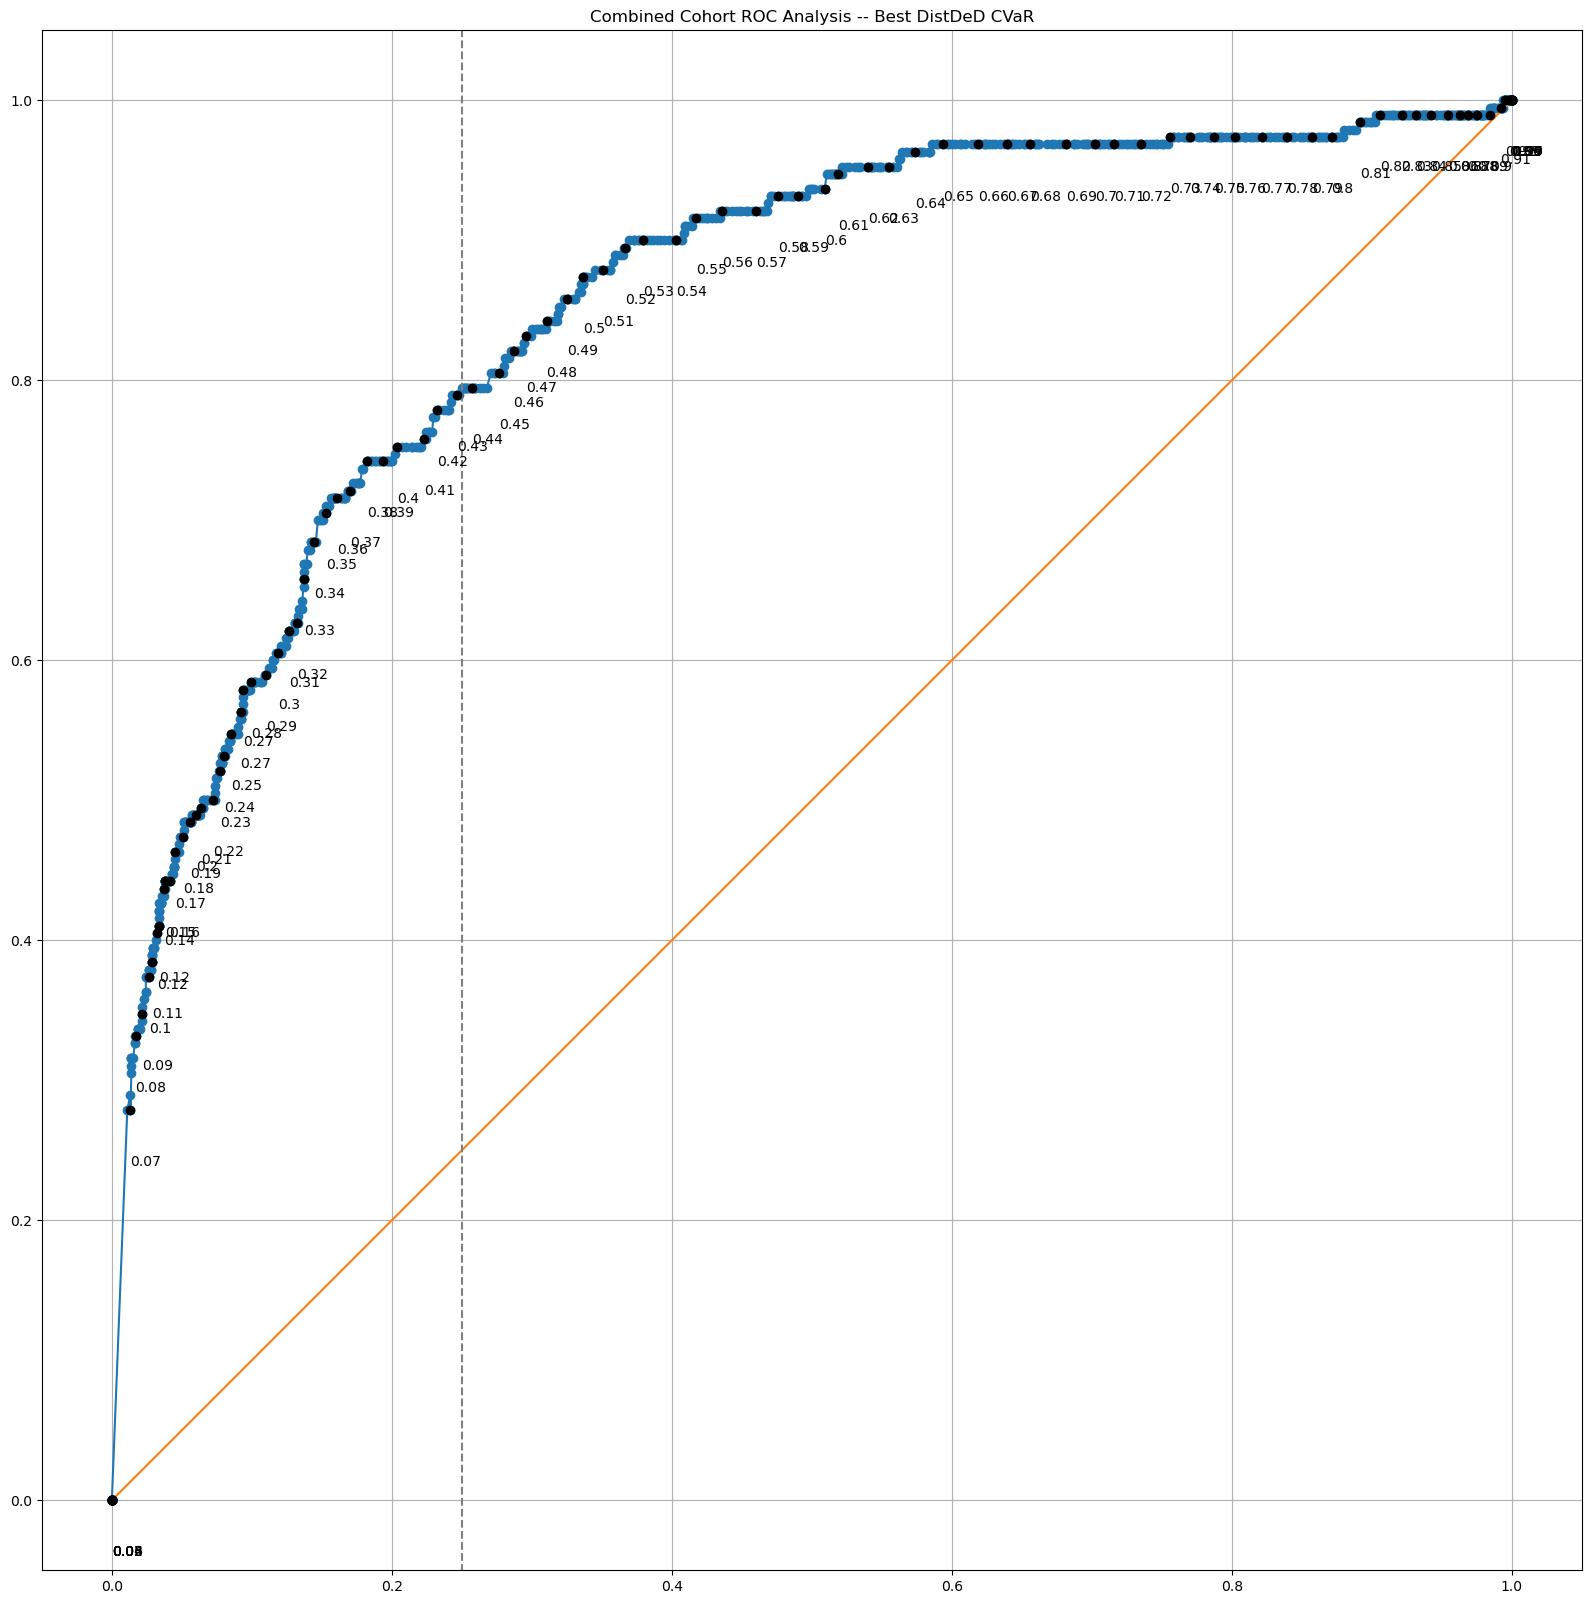

In [103]:
plt.subplots(figsize=(20, 20))
plt.plot(fpr_comb[:,cvar_idx_comb], tpr_comb[:,cvar_idx_comb], 'o-', label="ROC curve")
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), label="diagonal")
plt.axvline(x=0.25, ymin=-0.05, ymax=1.05, linestyle='--', color='gray')
for x, y, txt in zip(fpr_comb[::10, cvar_idx_comb], tpr_comb[::10, cvar_idx_comb], thres_comb[::10, cvar_idx_comb]):
    plt.plot(x, y, c='black', marker='o')
    plt.annotate(np.round(txt,2), (x, y-0.04))
plt.grid()
plt.axis('square')
plt.title('Combined Cohort ROC Analysis -- Best DistDeD CVaR')
plt.show()

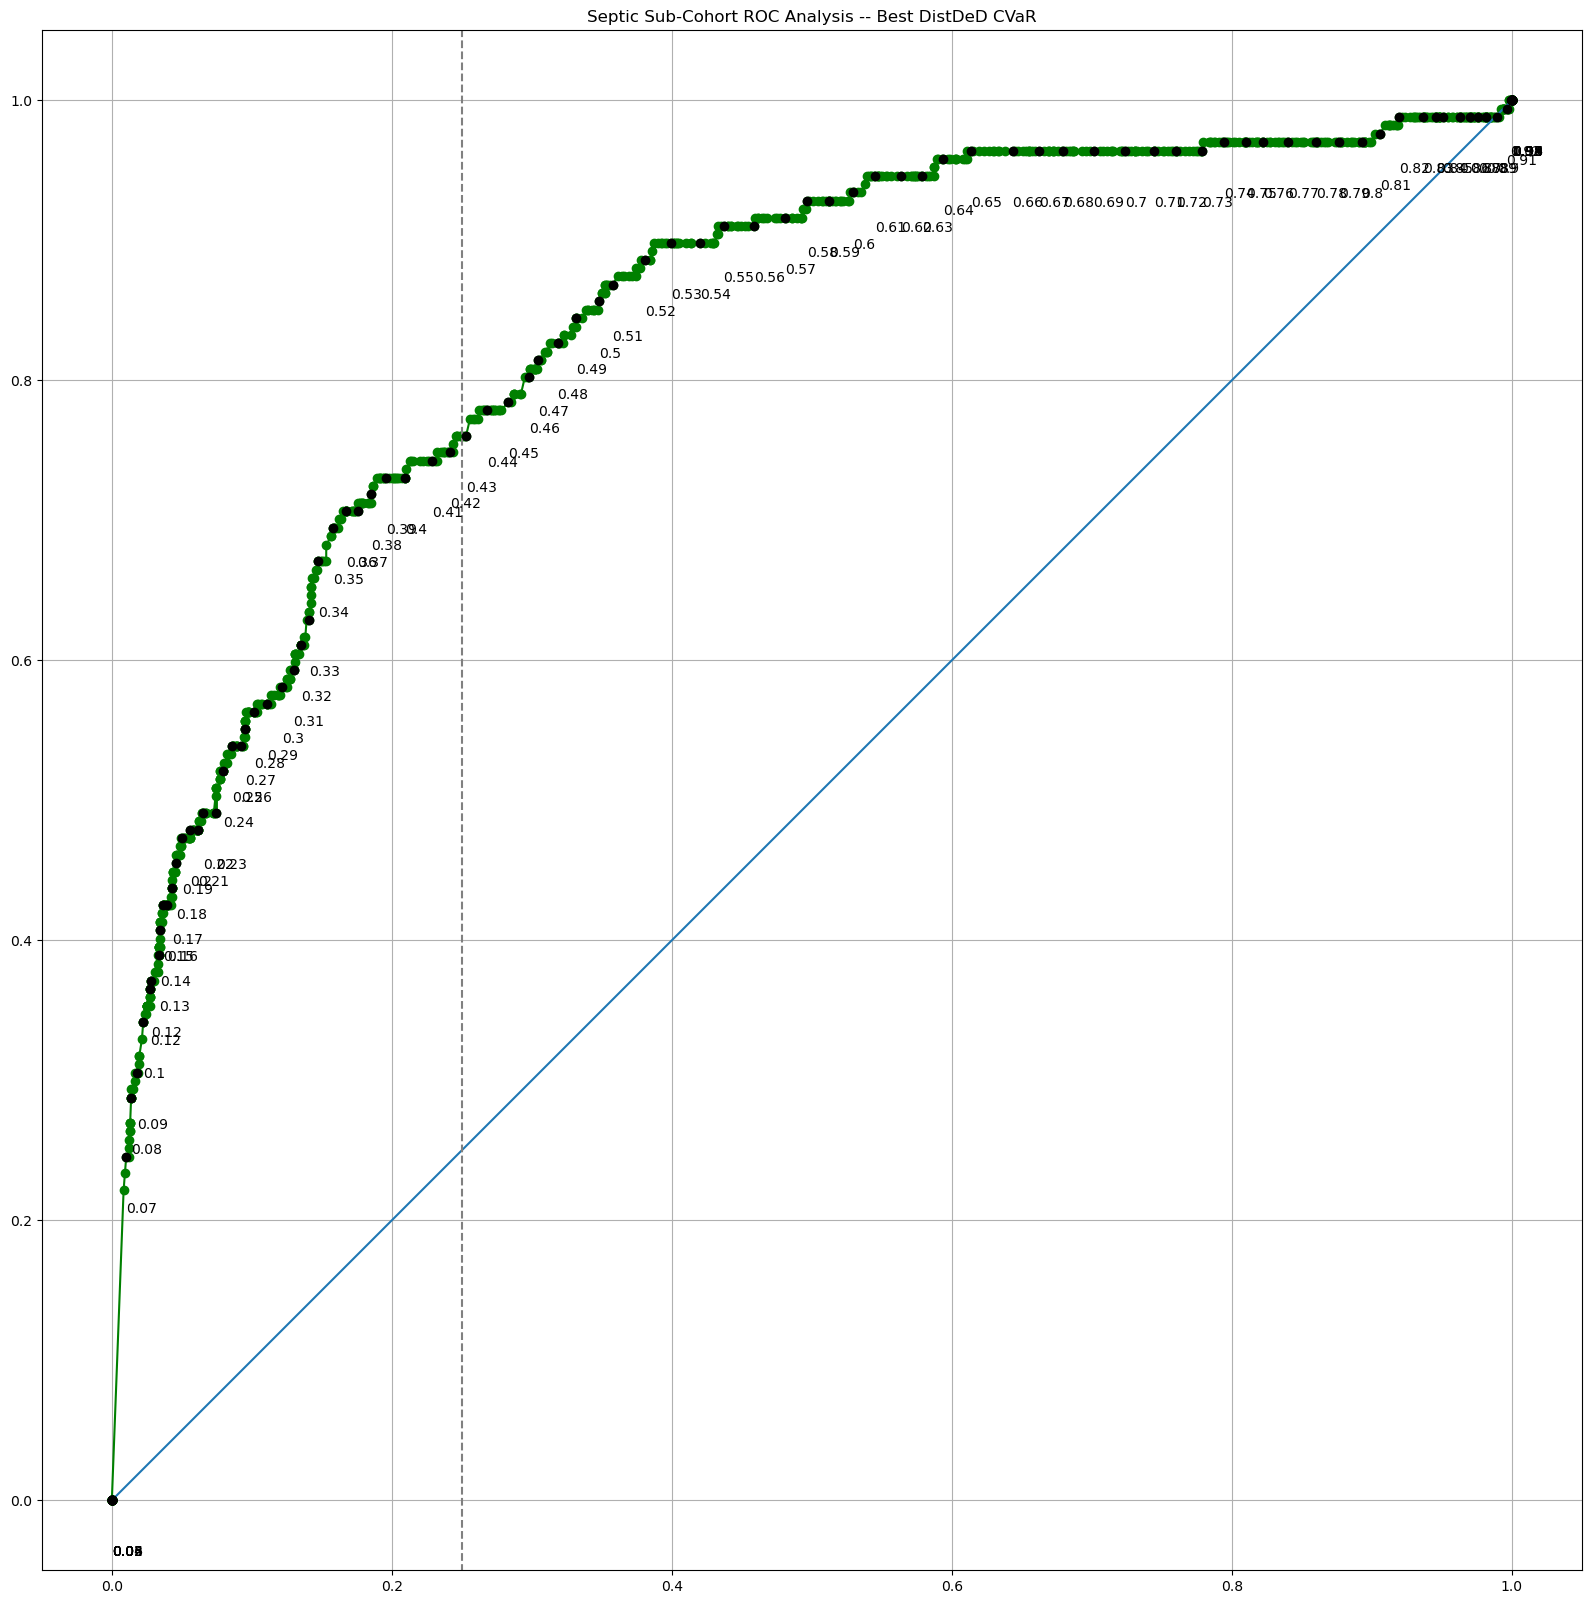

In [104]:
plt.subplots(figsize=(20, 20))
plt.plot(fpr_SEP[:,cvar_idx_SEP], tpr_SEP[:,cvar_idx_SEP], 'o-', label="ROC curve", color='green')
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), label="diagonal")
plt.axvline(x=0.25, ymin=-0.05, ymax=1.05, linestyle='--', color='gray')
for x, y, txt in zip(fpr_SEP[::10, cvar_idx_SEP], tpr_SEP[::10, cvar_idx_SEP], thres_SEP[::10, cvar_idx_SEP]):
    plt.plot(x, y, c='black', marker='o')
    plt.annotate(np.round(txt,2), (x, y-0.04))
plt.grid()
plt.axis('square')
plt.title('Septic Sub-Cohort ROC Analysis -- Best DistDeD CVaR')
plt.show()

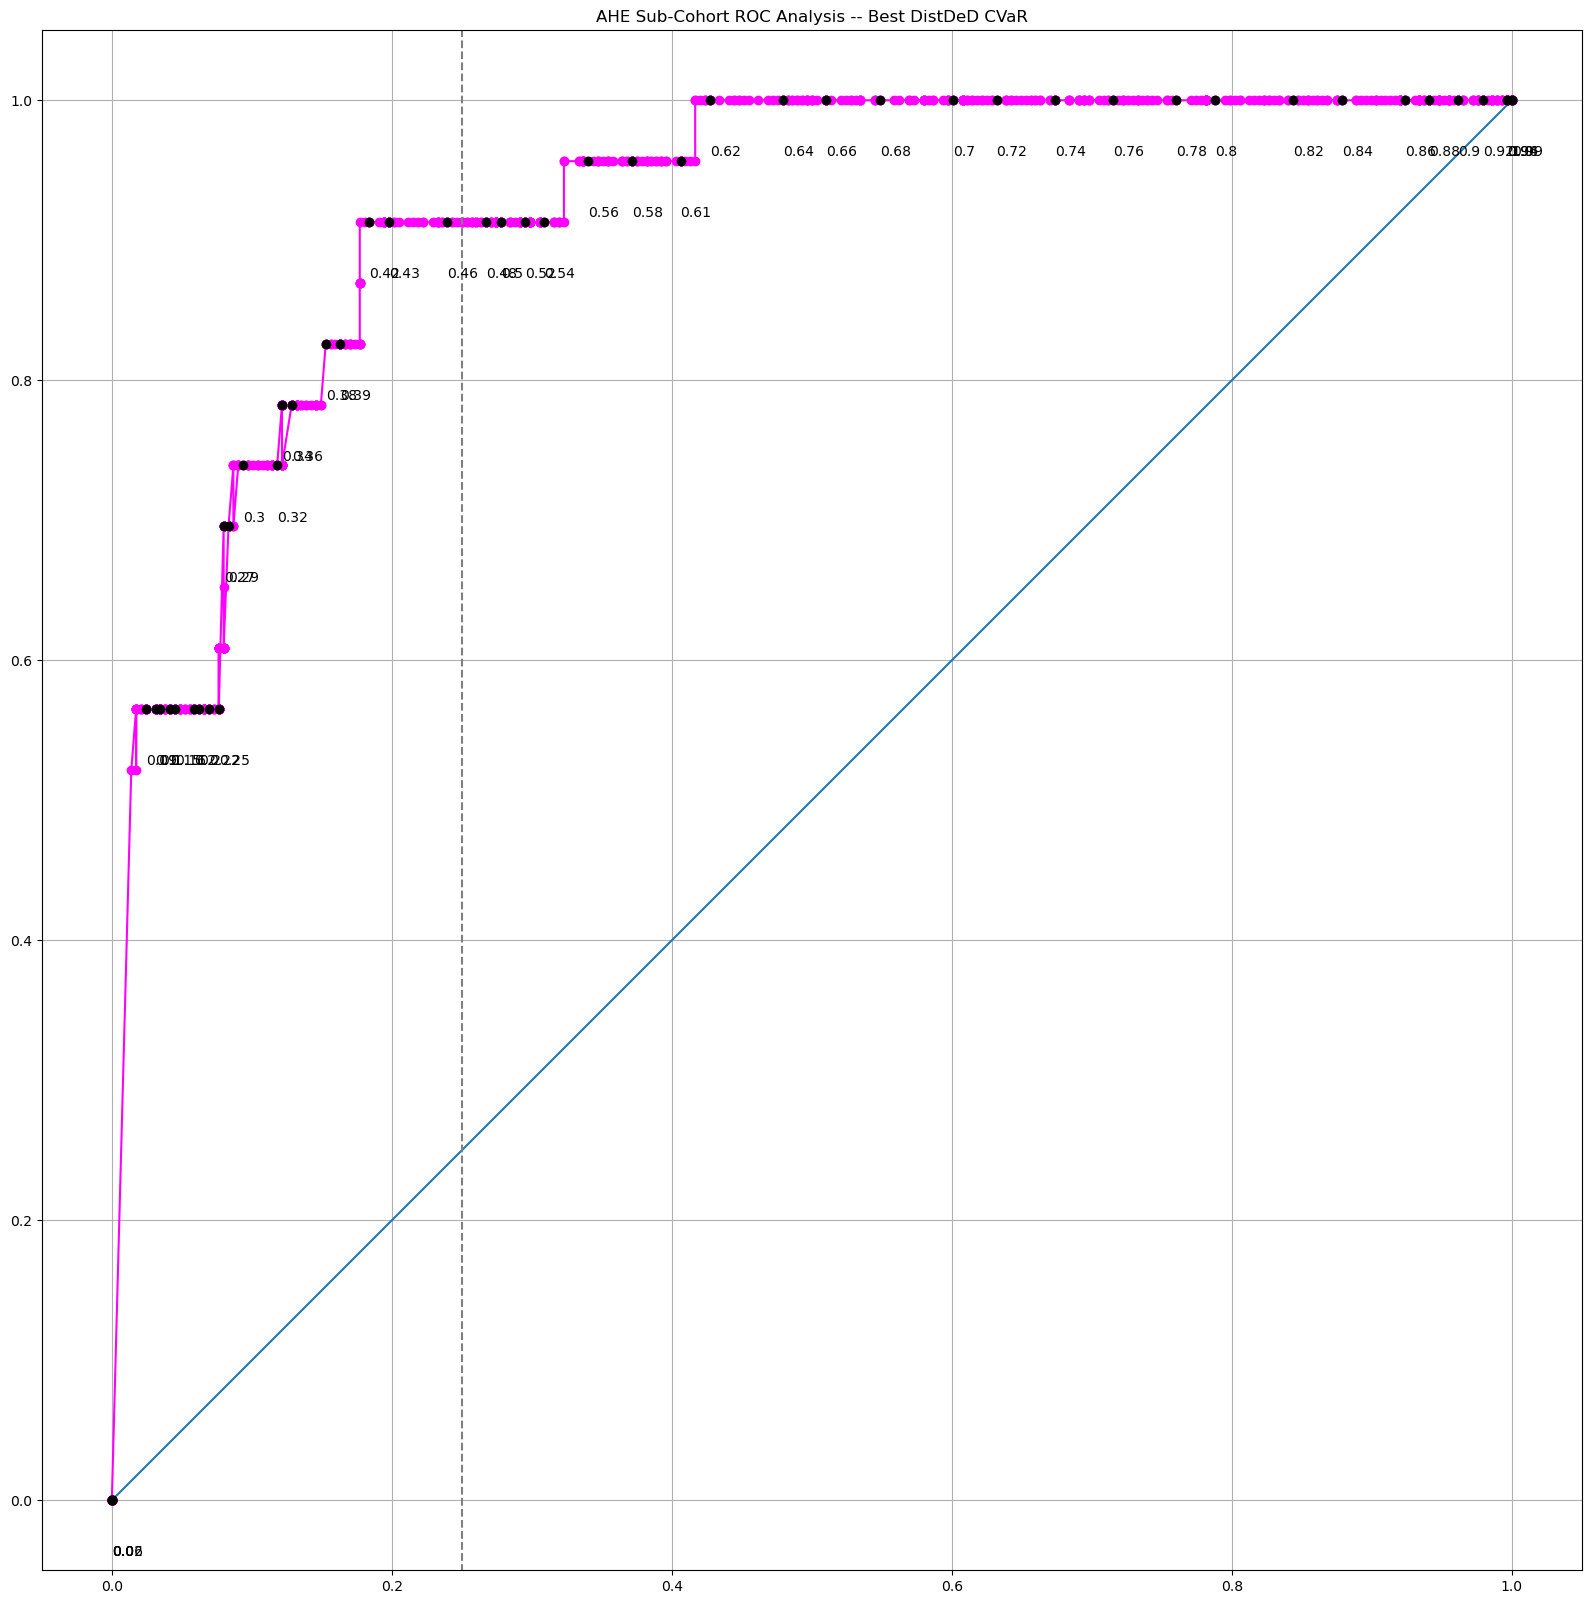

In [105]:
plt.subplots(figsize=(20, 20))
plt.plot(fpr_AHE[:,cvar_idx_AHE], tpr_AHE[:,cvar_idx_AHE], 'o-', label="ROC curve", color='magenta')
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), label="diagonal")
plt.axvline(x=0.25, ymin=-0.05, ymax=1.05, linestyle='--', color='gray')
for x, y, txt in zip(fpr_AHE[::20, cvar_idx_AHE], tpr_AHE[::20, cvar_idx_AHE], thres_AHE[::20, cvar_idx_AHE]):
    plt.plot(x, y, c='black', marker='o')
    plt.annotate(np.round(txt,2), (x, y-0.04))
plt.grid()
plt.axis('square')
plt.title('AHE Sub-Cohort ROC Analysis -- Best DistDeD CVaR')
plt.show()

In [183]:
print(f'Total Number of AHE Patients: {len(nonsurv_AHE_trajs)+len(surv_AHE_trajs)}, where {len(surv_AHE_trajs)} survived and {len(nonsurv_AHE_trajs)} did not')
print(f'Total Number of Sepsis Patients: {len(nonsurv_SEP_trajs)+len(surv_SEP_trajs)}, where {len(surv_SEP_trajs)} survived and {len(nonsurv_SEP_trajs)} did not')

Total Number of AHE Patients: 311, where 288 survived and 23 did not
Total Number of Sepsis Patients: 1238, where 1071 survived and 167 did not


In [106]:
tpr_comb[fpr_comb[:,cvar_idx_comb]<=0.25,cvar_idx_comb][-1], tpr_SEP[fpr_SEP[:,cvar_idx_SEP]<=0.25, cvar_idx_SEP][-1], tpr_AHE[fpr_AHE[:,cvar_idx_AHE]<=0.25, cvar_idx_AHE][-1]

(0.7894736842105263, 0.7604790419161677, 0.9130434782608695)

In [107]:
thres_comb[fpr_comb[:,cvar_idx_comb]<=0.25, cvar_idx_comb][-1], thres_SEP[fpr_SEP[:,cvar_idx_SEP]<=0.25,cvar_idx_SEP][-1], thres_AHE[fpr_AHE[:,cvar_idx_AHE]<=0.25,cvar_idx_AHE][-1]

(0.431, 0.427, 0.466)

In [108]:
thr_comb = thres_comb[fpr_comb[:,cvar_idx_comb]<=0.25, cvar_idx_comb][-1]
thr_SEP = thres_SEP[fpr_SEP[:, cvar_idx_SEP]<=0.25, cvar_idx_SEP][-1]
thr_AHE = thres_AHE[fpr_AHE[:, cvar_idx_AHE]<=0.25, cvar_idx_AHE][-1]

In [109]:
thres_comb.shape

(1001, 50)

In [110]:
np.max(auc_comb_out[1:]), np.max(auc_SEP_out[1:]), np.max(auc_AHE_out[1:])

array([0.  , 0.02, 0.04, 0.06, 0.08])

In [112]:
# Pull off the DistDeD \delta_r from the collected thresholds based on an FPR of 0.25
thr_arr_comb = {} # dict, keyed by the VaR threshold? values are a tuple {\delta_r, AUC, TPR}
thr_arr_SEP = {} # dict, keyed by the VaR threshold? values are a tuple {\delta_r, AUC, TPR}
thr_arr_AHE = {} # dict, keyed by the VaR threshold? values are a tuple {\delta_r, AUC, TPR}

for i_var, var_th in enumerate(VaR_thresholds):
    comb_tup = (thres_comb[fpr_comb[:, i_var]<=0.25, i_var][-1], auc_comb_out[i_var], tpr_comb[fpr_comb[:,i_var]<=0.25, i_var][-1])
    thr_arr_comb[var_th] = comb_tup
    
    SEP_tup = (thres_SEP[fpr_SEP[:, i_var]<=0.25, i_var][-1], auc_SEP_out[i_var], tpr_SEP[fpr_SEP[:,i_var]<=0.25, i_var][-1])
    thr_arr_SEP[var_th] = SEP_tup
    
    AHE_tup = (thres_AHE[fpr_AHE[:, i_var]<=0.25, i_var][-1], auc_AHE_out[i_var], tpr_AHE[fpr_AHE[:,i_var]<=0.25, i_var][-1])
    thr_arr_AHE[var_th] = AHE_tup


/pkgs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  """Entry point for launching an IPython kernel.
/pkgs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  
/pkgs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  This is separate from the ipykernel package so we can avoid doing imports until


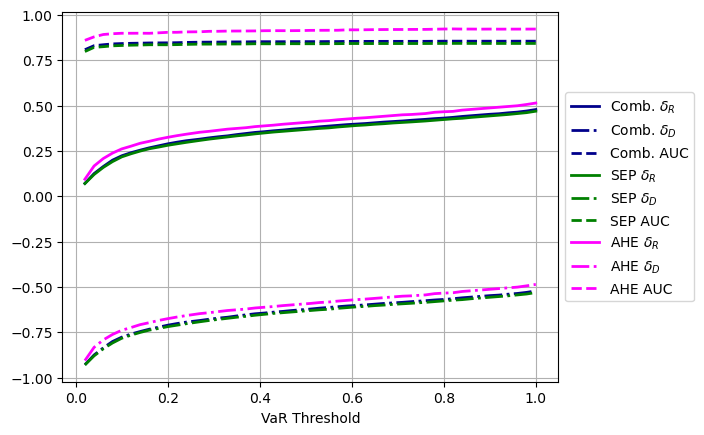

In [119]:
comb_thr_results = np.vstack(thr_arr_comb.values())
SEP_thr_results = np.vstack(thr_arr_SEP.values())
AHE_thr_results = np.vstack(thr_arr_AHE.values())

plt.figure()
plt.plot(VaR_thresholds[1:], comb_thr_results[1:, 0], lw=2, color='darkblue', label='Comb. $\delta_R$')
plt.plot(VaR_thresholds[1:], comb_thr_results[1:, 0]-1, lw=2, color='darkblue', linestyle='-.', label='Comb. $\delta_D$')
plt.plot(VaR_thresholds[1:], comb_thr_results[1:, 1], lw=2, color='darkblue', linestyle='--', label='Comb. AUC')
plt.plot(VaR_thresholds[1:], SEP_thr_results[1:, 0], lw=2, color='green', label='SEP $\delta_R$')
plt.plot(VaR_thresholds[1:], SEP_thr_results[1:, 0]-1, lw=2, color='green', linestyle='-.', label='SEP $\delta_D$')
plt.plot(VaR_thresholds[1:], SEP_thr_results[1:, 1], lw=2, color='green', linestyle='--', label='SEP AUC')
plt.plot(VaR_thresholds[1:], AHE_thr_results[1:, 0], lw=2, color='magenta', label='AHE $\delta_R$')
plt.plot(VaR_thresholds[1:], AHE_thr_results[1:, 0]-1, lw=2, color='magenta', linestyle='-.', label='AHE $\delta_D$')
plt.plot(VaR_thresholds[1:], AHE_thr_results[1:, 1], lw=2, color='magenta', linestyle='--', label='AHE AUC')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('VaR Threshold')
plt.grid()
plt.show()

In [37]:
test_traj = nonsurv_trajs[0]
test_df = value_df[value_df.traj==test_traj]
test_df.head()

,traj,step,s,a,q_dn,q_rn,category,stay_id,presumed_onset,pt_type,cvar_dn,cvar_rn,dn_sel_act,rn_sel_act,v_dn,v_rn
50,1,0,"[0.5081132, -0.90833366, 0.70387465, 0.3366231...",24,"[[-0.22555503, -0.14821419, -0.13904227, -0.14...","[[0.7916978, 0.6937408, 0.6839838, 0.6880705, ...",-1,33922519.0,-49.0,Sepsis,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.09415103495121002, -0.080473020672798...","[nan, 0.8159421682357788, 0.8405247926712036, ...","[nan, -0.11539353430271149, -0.102969601750373...","[nan, 0.7800806760787964, 0.7980253100395203, ..."
51,1,1,"[1.1806666, -1.1312634, 0.50835913, -0.3495395...",9,"[[-0.11148496, -0.18448256, -0.14192182, -0.11...","[[0.80245984, 0.68061686, 0.6681006, 0.7166024...",-1,33922519.0,-49.0,Sepsis,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.055356670171022415, -0.04299173131585...","[nan, 0.7686188817024231, 0.7934525012969971, ...","[nan, -0.08175963908433914, -0.066515170037746...","[nan, 0.832309901714325, 0.8596318960189819, 0..."
52,1,2,"[0.83170414, -0.76759624, 0.64636785, -0.06577...",9,"[[-0.108176164, -0.13336542, -0.110951945, -0....","[[0.7897466, 0.68528736, 0.6829317, 0.7005209,...",-1,33922519.0,-49.0,Sepsis,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.06453734636306763, -0.051234252750873...","[nan, 0.7686487436294556, 0.790939211845398, 0...","[nan, -0.06453734636306763, -0.058309417217969...","[nan, 0.8144391179084778, 0.8371427655220032, ..."
53,1,3,"[1.1514413, -0.97916466, 0.73315954, 0.2423259...",9,"[[-0.11219007, -0.15814148, -0.14142337, -0.12...","[[0.7501719, 0.65106666, 0.64436275, 0.6709396...",-1,33922519.0,-49.0,Sepsis,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.06189756467938423, -0.056010521948337...","[nan, 0.7306861281394958, 0.7680474519729614, ...","[nan, -0.07079274952411652, -0.064160749316215...","[nan, 0.7848454713821411, 0.8139649629592896, ..."
54,1,4,"[1.3643419, -1.1956053, 1.0377512, 0.17993748,...",24,"[[-0.12997535, -0.16518462, -0.16974819, -0.15...","[[0.705914, 0.61474556, 0.6012078, 0.63431555,...",-1,33922519.0,-49.0,Sepsis,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.0557299479842186, -0.0440974310040473...","[nan, 0.7772651314735413, 0.8138009309768677, ...","[nan, -0.0828574001789093, -0.0725805908441543...","[nan, 0.7534087300300598, 0.790300726890564, 0..."


In [38]:
test_df.shape

(49, 16)

In [39]:
Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])
V_D = np.vstack([j[None, ...] for j in test_df['v_dn'].values])
V_R = np.vstack([j[None, ...] for j in test_df['v_rn'].values])

In [40]:
Z_D.shape, Z_R.shape, V_D.shape, V_R.shape

((49, 50, 25), (49, 50, 25), (49, 50), (49, 50))

In [41]:
z_d = Z_D[:,-1,:]
z_r = Z_R[:,-1,:]
v_d = V_D[:, -1]
v_r = V_R[:, -1]

In [43]:
flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
flag_summary = np.sum(flag_test, axis=-1)/flag_test.shape[-1]

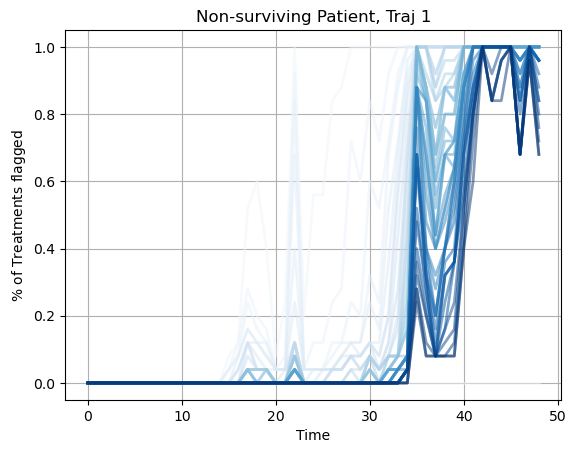

In [44]:
colors = sns.color_palette("Blues", n_colors=flag_test.shape[1])
plt.figure()
for i in range(flag_test.shape[1]):
    plt.plot(np.arange(flag_test.shape[0]), flag_summary[:, i], lw=2, alpha=0.5, color=colors[i])
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"Non-surviving Patient, Traj {test_traj}")
plt.show()

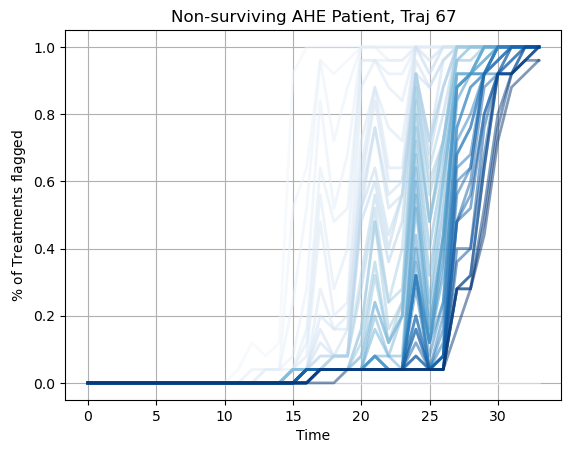

In [184]:
# test_traj = nonsurv_trajs[0]
test_traj = nonsurv_AHE_trajs[0]
# test_traj = nonsurv_SEP_trajs[0]

test_df = value_df[value_df.traj==test_traj]

Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

# flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
# flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)

flag_summary = np.sum(flag_test, axis=-1)/flag_test.shape[-1]

colors = sns.color_palette("Blues", n_colors=flag_test.shape[1])
plt.figure()
for i in range(flag_test.shape[1]):
    plt.plot(np.arange(flag_test.shape[0]), flag_summary[:, i], lw=2, alpha=0.5, color=colors[i])
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
# plt.title(f"Non-surviving Patient, Traj {test_traj}")
plt.title(f"Non-surviving AHE Patient, Traj {test_traj}")
# plt.title(f"Non-surviving Sepsis Patient, Traj {test_traj}")
plt.show()

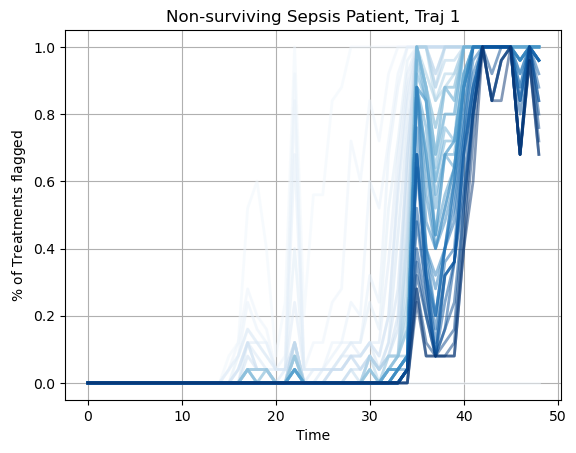

In [167]:
# test_traj = nonsurv_trajs[0]
# test_traj = nonsurv_AHE_trajs[0]
test_traj = nonsurv_SEP_trajs[0]

test_df = value_df[value_df.traj==test_traj]

Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

# flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
# flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)

flag_summary = np.sum(flag_test, axis=-1)/flag_test.shape[-1]

colors = sns.color_palette("Blues", n_colors=flag_test.shape[1])
plt.figure()
for i in range(flag_test.shape[1]):
    plt.plot(np.arange(flag_test.shape[0]), flag_summary[:, i], lw=2, alpha=0.5, color=colors[i])
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
# plt.title(f"Non-surviving Patient, Traj {test_traj}")
# plt.title(f"Non-surviving AHE Patient, Traj {test_traj}")
plt.title(f"Non-surviving Sepsis Patient, Traj {test_traj}")
plt.show()

In [185]:
action_mask = test_df['a'].values
action_mask.shape, type(action_mask)

((34,), numpy.ndarray)

In [186]:
action_mask_array = np.ones((len(action_mask), 25))
action_idx = np.concatenate([np.arange(len(action_mask))[None,...], action_mask[None,...]], axis=0)
flat_index_array = np.ravel_multi_index(action_idx, action_mask_array.shape)
np.ravel(action_mask_array)[flat_index_array] = 0

In [187]:
action_mask

array([ 0,  0,  0,  0,  0,  0,  0, 15, 20, 20,  0,  5,  5,  5,  5, 15,  5,
       20, 20,  5,  5, 15,  5,  5, 15,  5,  5,  5,  5,  5,  5,  5,  5,  0])

In [188]:
action_mask_array[:3]

array([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [189]:
import matplotlib

In [190]:
norm = matplotlib.colors.Normalize(-1, 0)
colors = [[norm(-1.0), "xkcd:tomato"],
          [norm(-0.8), "xkcd:tomato"],
          [norm(-0.55), "xkcd:tomato"],
          [norm(-0.5), "xkcd:custard"],
          [norm(-0.4), "xkcd:custard"],
          [norm(-0.2), "white"],
          [norm(-0.0), "white"]]

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)

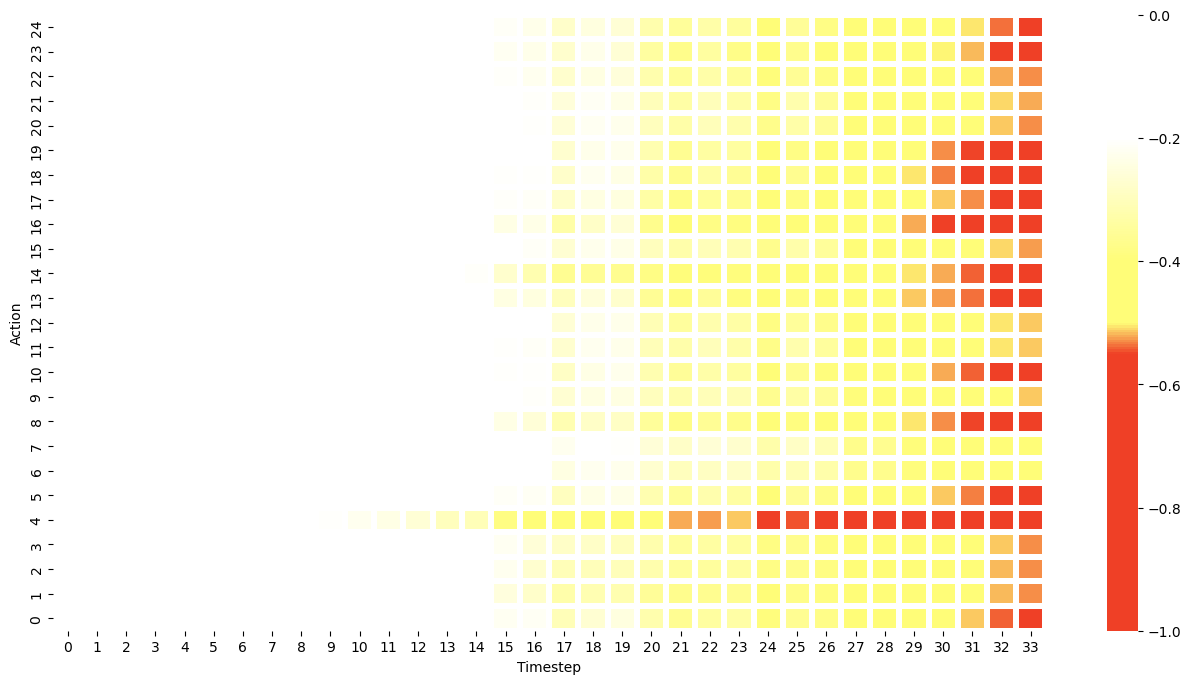

In [191]:
plt.figure(figsize=(16,8))
ax = sns.heatmap(np.transpose(Z_D[:, -1, :]), vmin=-1, vmax=0, cmap=cmap, linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.show()

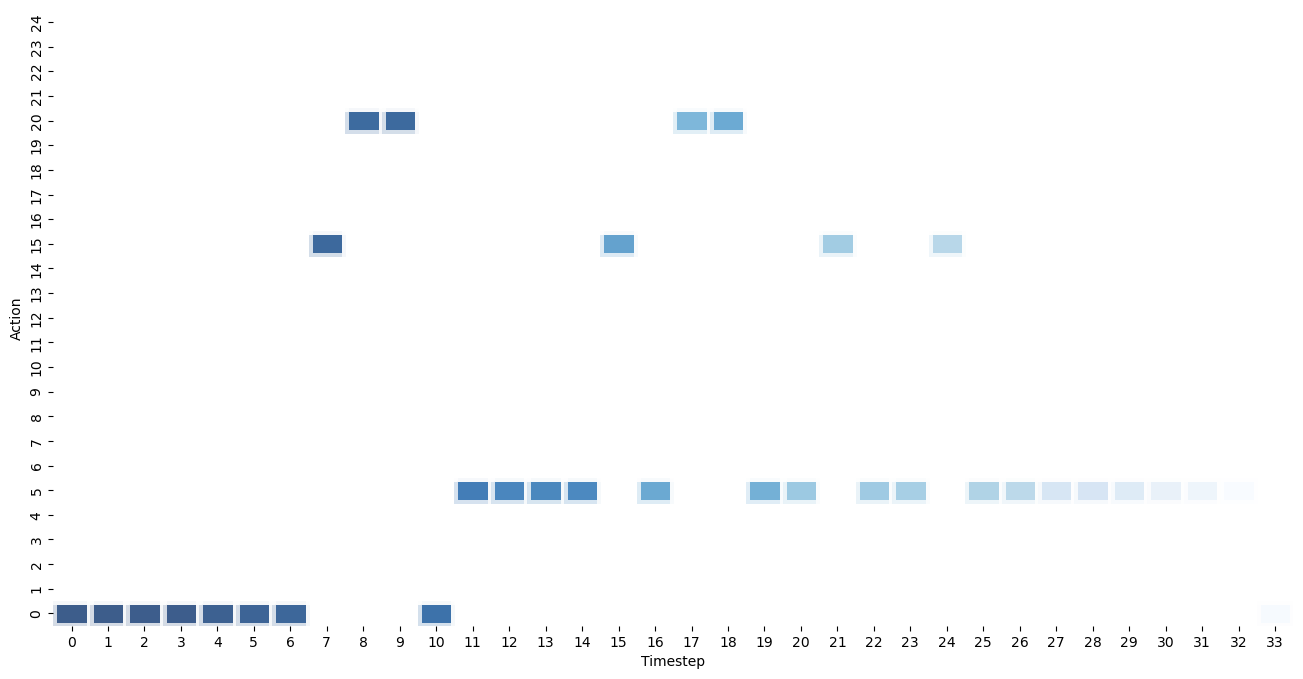

In [192]:
plt.figure(figsize=(16,8))
ax = sns.heatmap(np.transpose(Z_D[:, -1, :]), cmap="Blues", linewidths=5, linecolor='white', mask=np.transpose(action_mask_array), alpha=0.785, cbar=False)
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.show()

In [193]:
type(action_mask_array)

numpy.ndarray

In [194]:
action_idx

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31,
        32, 33],
       [ 0,  0,  0,  0,  0,  0,  0, 15, 20, 20,  0,  5,  5,  5,  5, 15,
         5, 20, 20,  5,  5, 15,  5,  5, 15,  5,  5,  5,  5,  5,  5,  5,
         5,  0]])

In [195]:
from matplotlib.patches import Rectangle

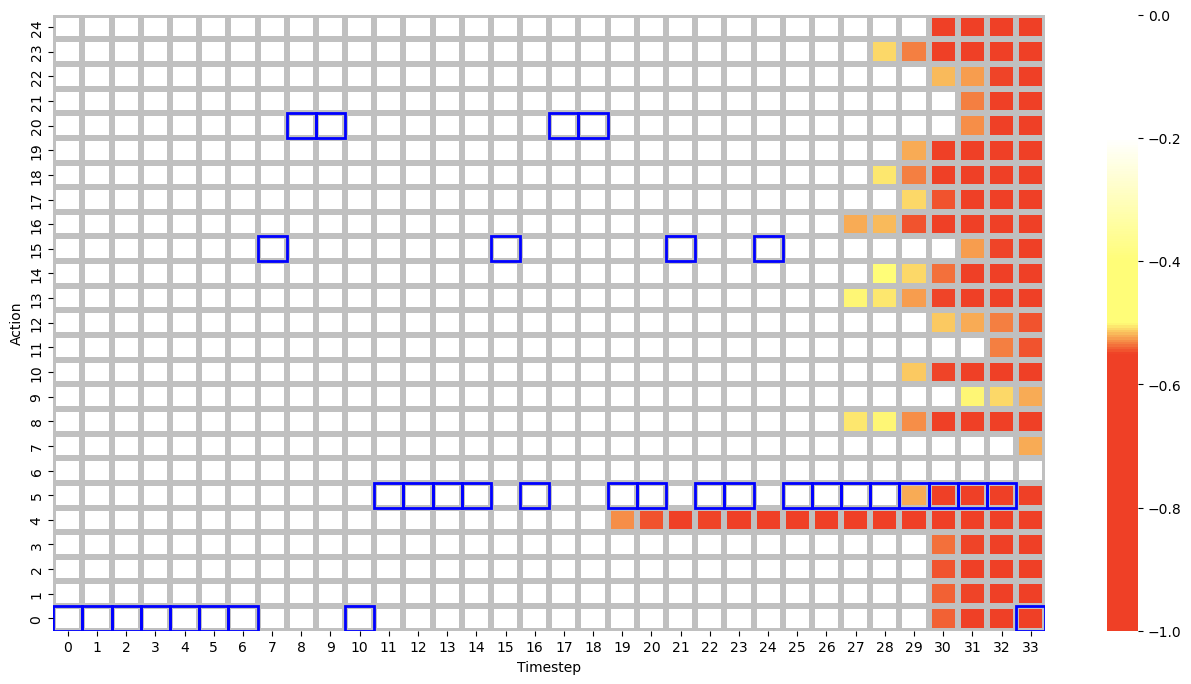

In [196]:
zd, zr = Z_D[:, -1, :], Z_R[:, -1, :]-1

flagged_acts = flag_test[:,-1,:]

plt.figure(figsize=(16,8))
ax = sns.heatmap(np.transpose(np.mean(np.concatenate((zd[...,np.newaxis], zr[...,np.newaxis]), axis=-1), axis=-1)), vmin=-1, vmax=0, mask=np.transpose(~flagged_acts), cmap=cmap, linewidths=3, linecolor='silver')
# ax.scatter(action_idx[0,:]+0.5, action_idx[1,:]+0.5, s=45, marker='s', linewidth=2, facecolor=None)
for i_time in range(zd.shape[0]):
    ax.add_patch(Rectangle((action_idx[0,i_time], action_idx[1,i_time]), 1, 1, fill=False, edgecolor='blue', lw=2))
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.show()

In [197]:
value_df.groupby('traj').size().max()

73

In [206]:
# Create arrays for "Max Size" to track when actions are flagged and at what frequency... 
# I'm going to be doing this for all splits of the data to try and get a sense of what makes sense
#   in comparison between 'all', 'Sepsis', 'AHE', 'Survivors', 'Non-survivors'
flag_counts_all = np.zeros((73, 25)) # The entirety of the dataframe...
num_trajs_all = np.zeros((73, 25))  # Used to "normalize" the flag_counts
flagged_act_all = []

flag_counts_ns_comb = np.zeros((73, 25)) # ALL Non-surviving Patients
num_trajs_ns_comb = np.zeros((73, 25))  # Used to "normalize" the flag_counts
flagged_act_ns_comb = []

flag_counts_ns_SEP = np.zeros((73, 25)) # Non-surviving Sepsis Patients
num_trajs_ns_SEP = np.zeros((73, 25))  # Used to "normalize" the flag_counts
flagged_act_ns_SEP = []

flag_counts_ns_AHE = np.zeros((73, 25)) # Non-surviving AHE Patients
num_trajs_ns_AHE = np.zeros((73, 25))  # Used to "normalize" the flag_counts
flagged_act_ns_AHE = []

flag_counts_surv_comb = np.zeros((73, 25)) # ALL Surviving Patients
num_trajs_surv_comb = np.zeros((73, 25))  # Used to "normalize" the flag_counts
flagged_act_surv_comb = []

flag_counts_surv_SEP = np.zeros((73, 25)) # Surviving Sepsis Patients
num_trajs_surv_SEP = np.zeros((73, 25))  # Used to "normalize" the flag_counts
flagged_act_surv_SEP = []

flag_counts_surv_AHE = np.zeros((73, 25)) # Surviving AHE Patients
num_trajs_surv_AHE = np.zeros((73, 25))  # Used to "normalize" the flag_counts
flagged_act_surv_AHE = []

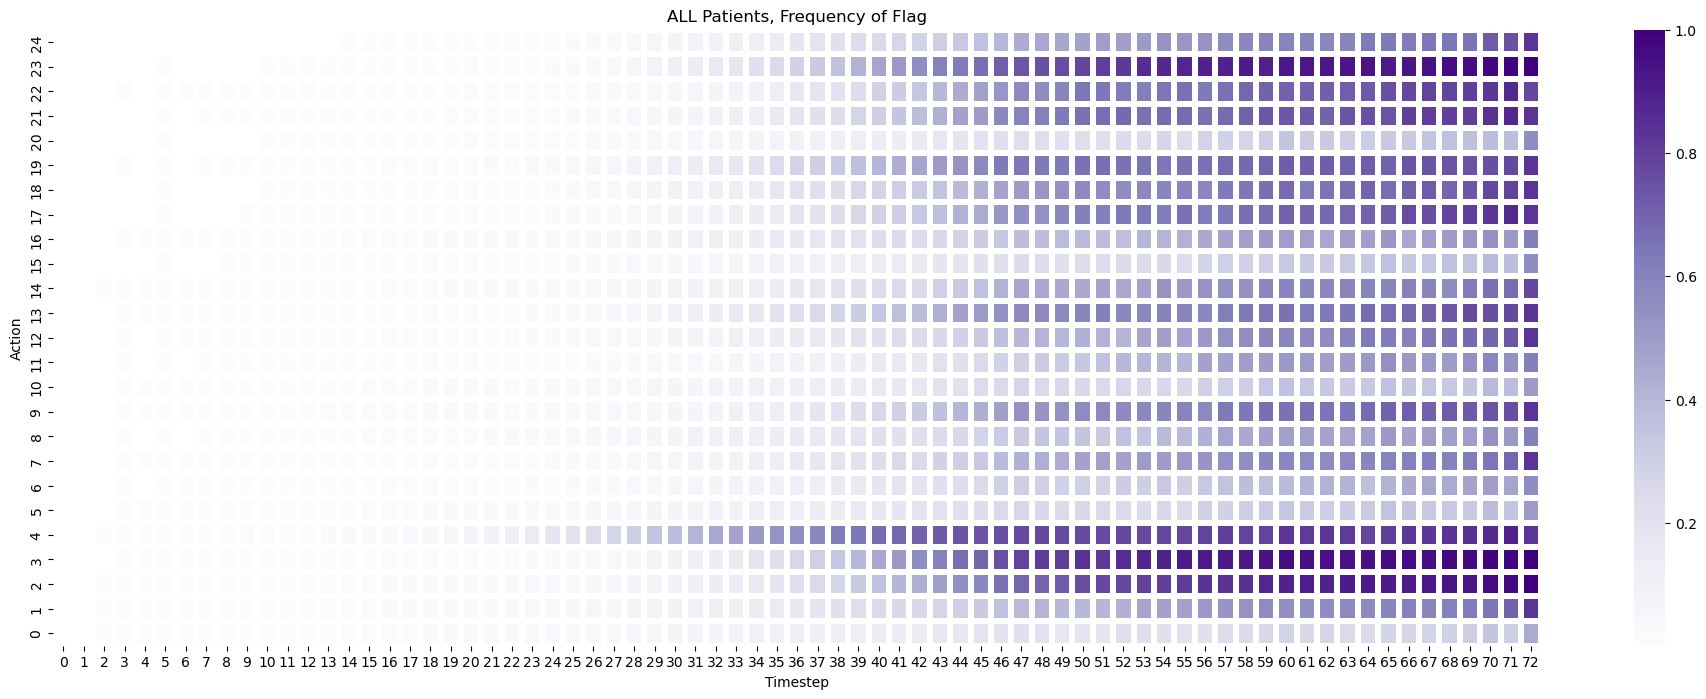

In [207]:
# Consider ALL patients
for traj in value_df.traj.unique():
    test_df = value_df[value_df.traj==traj]

    Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
    Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

    flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
    # flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
#     flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)
    flagged_acts = (flag_test[:, -1, :]).astype(int)  # Dimensions are num_steps (time) x num_acts, casting to integer
    
    flagged_act_all.append(np.sum(flagged_acts, axis=-1)/flagged_acts.shape[-1])
    
    num_steps = flagged_acts.shape[0]
    
    flag_counts_all[:num_steps, :] += flagged_acts
    # Account for the trajectory being "present" at each time step
    num_trajs_all[:num_steps, :] += np.ones_like(flagged_acts) 
    
normed_flag_counts = flag_counts_all/num_trajs_all
# normed_flag_counts = flag_counts_all/num_trajs_all.max()
    
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_flag_counts), cmap='Purples', mask=np.transpose(normed_flag_counts==0), linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("ALL Patients, Frequency of Flag")
plt.show()

/pkgs/anaconda3/lib/python3.7/site-packages/numpy/ma/core.py:4284: RuntimeWarning: invalid value encountered in multiply
  getdata(other)))


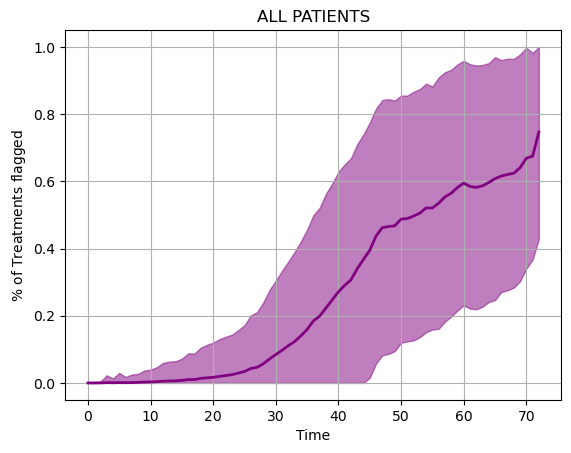

In [210]:
# Consolidate all of the arrays: 
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
lens = [len(i) for i in flagged_act_all]
arr = np.ma.empty((np.max(lens), len(flagged_act_all)))
arr.mask = True
for idx, l in enumerate(flagged_act_all):
    arr[:len(l), idx] = l
freq_mean, freq_std = arr.mean(axis=-1), arr.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2, color='purple')
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), color='purple', alpha=0.5)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL PATIENTS")
plt.show()

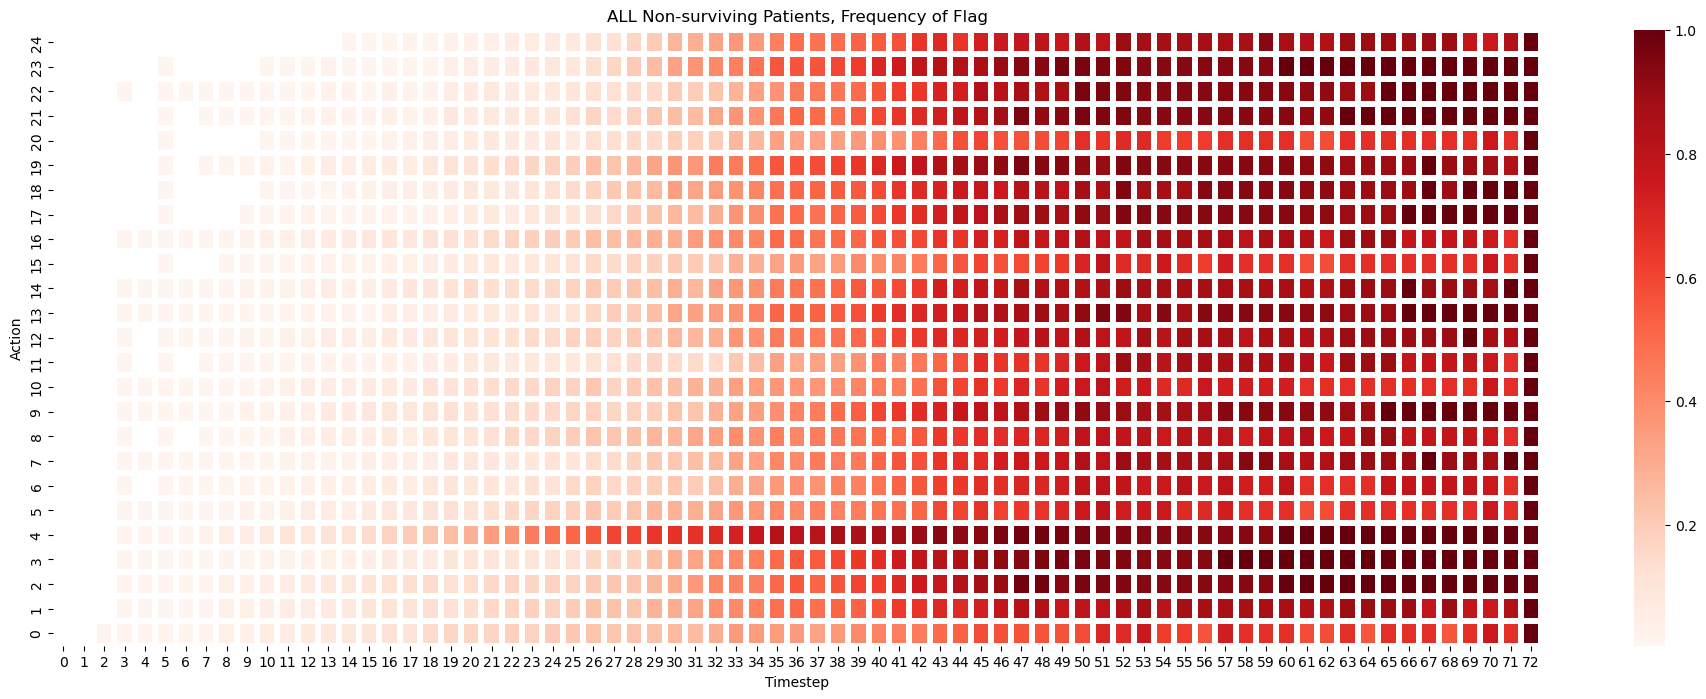

In [211]:
# Consider only nonsurviving patients
for traj in nonsurv_trajs:
    test_df = value_df[value_df.traj==traj]

    Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
    Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

    flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
    # flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
#     flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)
    flagged_acts = (flag_test[:, -1, :]).astype(int)  # Dimensions are num_steps (time) x num_acts, casting to integer
    
    num_steps = flagged_acts.shape[0]
    
    flagged_act_ns_comb.append(np.sum(flagged_acts, axis=-1)/flagged_acts.shape[-1])

    
    flag_counts_ns_comb[:num_steps, :] += flagged_acts
    # Account for the trajectory being "present" at each time step
    num_trajs_ns_comb[:num_steps, :] += np.ones_like(flagged_acts) 
    
normed_flag_counts = flag_counts_ns_comb/num_trajs_ns_comb
# normed_flag_counts = flag_counts_ns_comb/num_trajs_ns_comb.max()
    
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_flag_counts), cmap='Reds', mask=np.transpose(normed_flag_counts==0), linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("ALL Non-surviving Patients, Frequency of Flag")
plt.show()

Min. Traj Lengths: 9
Average Traj Length: 39.47894736842105
Max. Traj Lengths: 73


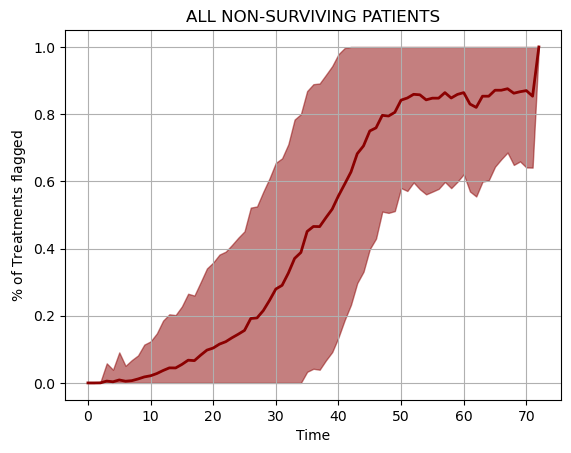

In [237]:
# Consolidate all of the arrays
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
lens = [len(i) for i in flagged_act_ns_comb]
print(f"Min. Traj Lengths: {np.min(lens)}")
print(f"Average Traj Length: {np.mean(lens)}")
print(f"Max. Traj Lengths: {np.max(lens)}")
arr = np.ma.empty((np.max(lens), len(flagged_act_ns_comb)))
arr.mask = True
for idx, l in enumerate(flagged_act_ns_comb):
    arr[:len(l), idx] = l
freq_mean, freq_std = arr.mean(axis=-1), arr.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2, color='darkred')
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), color='darkred', alpha=0.5)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL NON-SURVIVING PATIENTS")
plt.show()

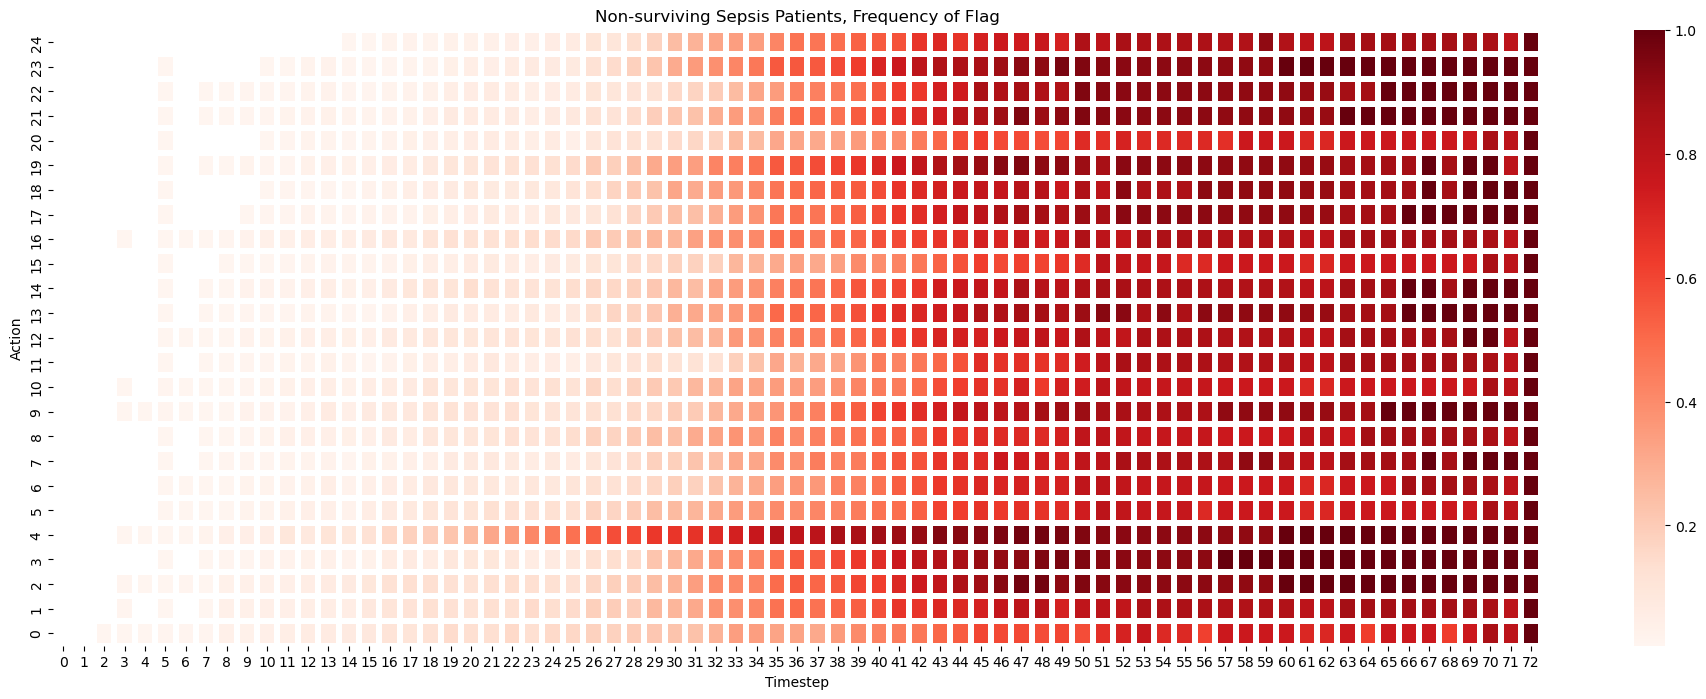

In [216]:
# Consider only nonsurviving SEPSIS patients
for traj in nonsurv_SEP_trajs:
    test_df = value_df[value_df.traj==traj]

    Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
    Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

#     flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
    # flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
    flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)
    flagged_acts = (flag_test[:, -1, :]).astype(int)  # Dimensions are num_steps (time) x num_acts, casting to integer
    
    num_steps = flagged_acts.shape[0]
    
    flagged_act_ns_SEP.append(np.sum(flagged_acts, axis=-1)/flagged_acts.shape[-1])

    
    flag_counts_ns_SEP[:num_steps, :] += flagged_acts
    # Account for the trajectory being "present" at each time step
    num_trajs_ns_SEP[:num_steps, :] += np.ones_like(flagged_acts) 
    
normed_flag_counts = flag_counts_ns_SEP/num_trajs_ns_SEP
# normed_flag_counts = flag_counts_ns_SEP/num_trajs_ns_SEP.max()
    
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_flag_counts), cmap='Reds', mask=np.transpose(normed_flag_counts==0), linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("Non-surviving Sepsis Patients, Frequency of Flag")
plt.show()

Min. Traj Lengths: 9
Average Traj Length: 40.08383233532934
Max. Traj Lengths: 73


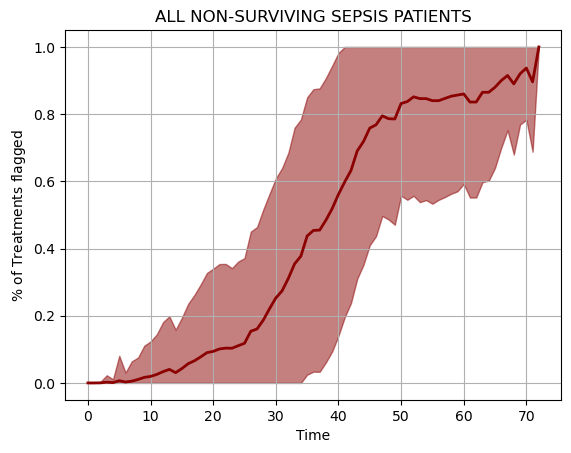

In [236]:
# Consolidate all of the arrays
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
lens = [len(i) for i in flagged_act_ns_SEP]
print(f"Min. Traj Lengths: {np.min(lens)}")
print(f"Average Traj Length: {np.mean(lens)}")
print(f"Max. Traj Lengths: {np.max(lens)}")
arr = np.ma.empty((np.max(lens), len(flagged_act_ns_SEP)))
arr.mask = True
for idx, l in enumerate(flagged_act_ns_SEP):
    arr[:len(l), idx] = l
freq_mean, freq_std = arr.mean(axis=-1), arr.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2, color='darkred')
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), color='darkred', alpha=0.5)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL NON-SURVIVING SEPSIS PATIENTS")
plt.show()

In [276]:
lens = [len(i) for i in flagged_act_ns_SEP]
max_len = np.max(lens)
arr = {}
for idx, l in enumerate(flagged_act_ns_SEP):
    resized = np.repeat(np.nan, max_len)
    foreign = np.linspace(0, max_len-1, len(l)).round().astype(int)
    resized[foreign] = l
    
    arr[idx] = resized
    
test = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in arr.items()])).interpolate().values

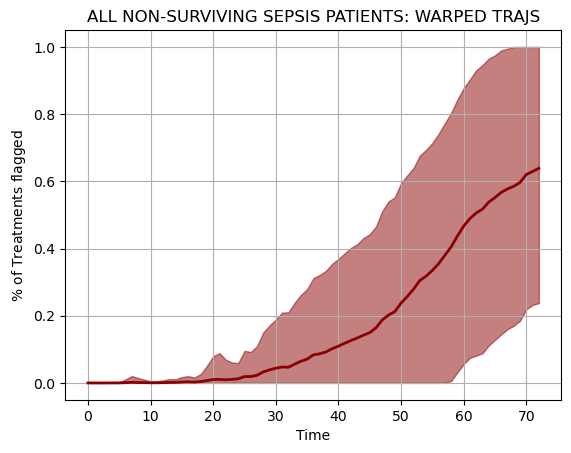

In [278]:
freq_mean, freq_std = test.mean(axis=-1), test.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2, color='darkred')
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), color='darkred', alpha=0.5)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL NON-SURVIVING SEPSIS PATIENTS: WARPED TRAJS")
plt.show()

/pkgs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in true_divide


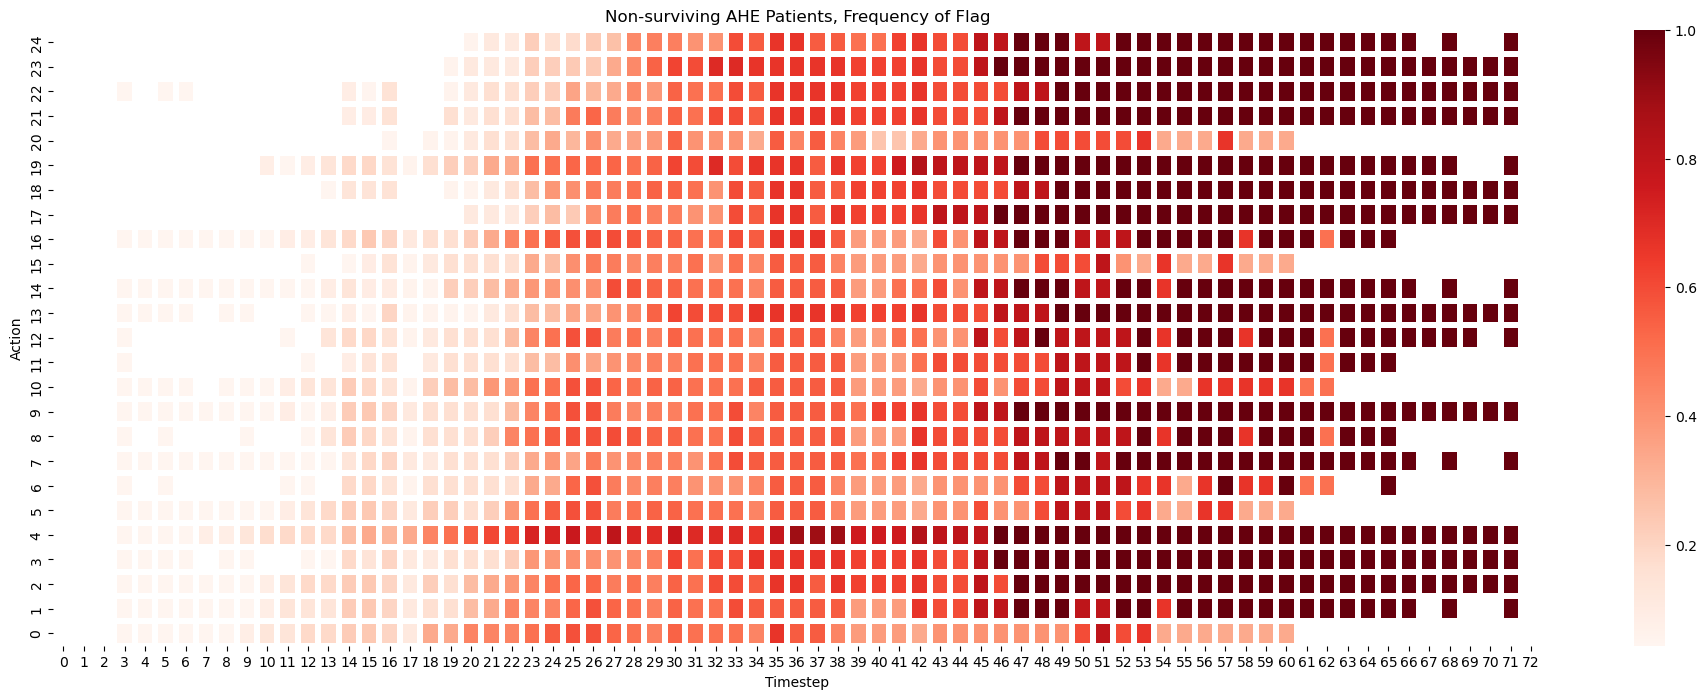

In [218]:
# Consider only nonsurviving SEPSIS patients
for traj in nonsurv_AHE_trajs:
    test_df = value_df[value_df.traj==traj]

    Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
    Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

#     flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
    flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
#     flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)
    flagged_acts = (flag_test[:, -2, :]).astype(int)  # Dimensions are num_steps (time) x num_acts, casting to integer
    
    num_steps = flagged_acts.shape[0]
    
    flagged_act_ns_AHE.append(np.sum(flagged_acts, axis=-1)/flagged_acts.shape[-1])

    
    flag_counts_ns_AHE[:num_steps, :] += flagged_acts
    # Account for the trajectory being "present" at each time step
    num_trajs_ns_AHE[:num_steps, :] += np.ones_like(flagged_acts) 
    
normed_flag_counts = flag_counts_ns_AHE/num_trajs_ns_AHE
# normed_flag_counts = flag_counts_ns_AHE/num_trajs_ns_AHE.max()
    
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_flag_counts), cmap='Reds', mask=np.transpose(normed_flag_counts==0), linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("Non-surviving AHE Patients, Frequency of Flag")
plt.show()

Min. Traj Lengths: 11
Average Traj Length: 35.08695652173913
Max. Traj Lengths: 72


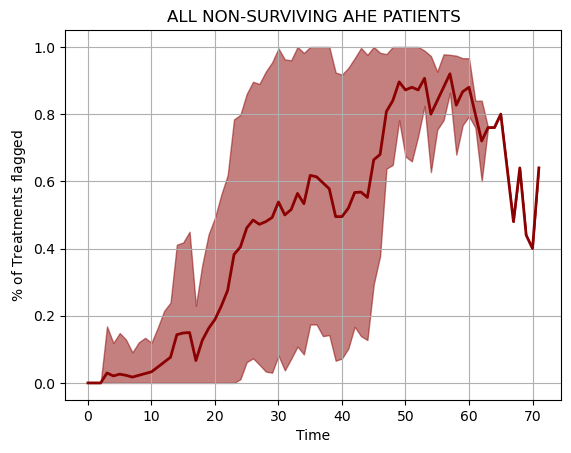

In [238]:
# Consolidate all of the arrays
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
lens = [len(i) for i in flagged_act_ns_AHE]
print(f"Min. Traj Lengths: {np.min(lens)}")
print(f"Average Traj Length: {np.mean(lens)}")
print(f"Max. Traj Lengths: {np.max(lens)}")
arr = np.ma.empty((np.max(lens), len(flagged_act_ns_AHE)))
arr.mask = True
for idx, l in enumerate(flagged_act_ns_AHE):
    arr[:len(l), idx] = l
freq_mean, freq_std = arr.mean(axis=-1), arr.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2, color='darkred')
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), color='darkred', alpha=0.5)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL NON-SURVIVING AHE PATIENTS")
plt.show()

In [279]:
lens = [len(i) for i in flagged_act_ns_AHE]
max_len = np.max(lens)
arr = {}
for idx, l in enumerate(flagged_act_ns_AHE):
    resized = np.repeat(np.nan, max_len)
    foreign = np.linspace(0, max_len-1, len(l)).round().astype(int)
    resized[foreign] = l
    
    arr[idx] = resized
    
test = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in arr.items()])).interpolate().values

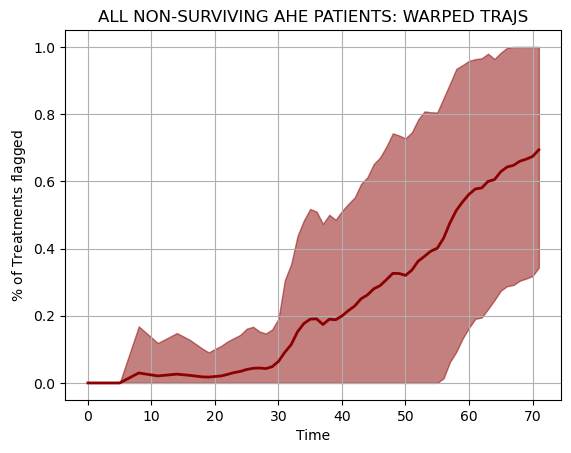

In [280]:
freq_mean, freq_std = test.mean(axis=-1), test.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2, color='darkred')
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), color='darkred', alpha=0.5)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL NON-SURVIVING AHE PATIENTS: WARPED TRAJS")
plt.show()

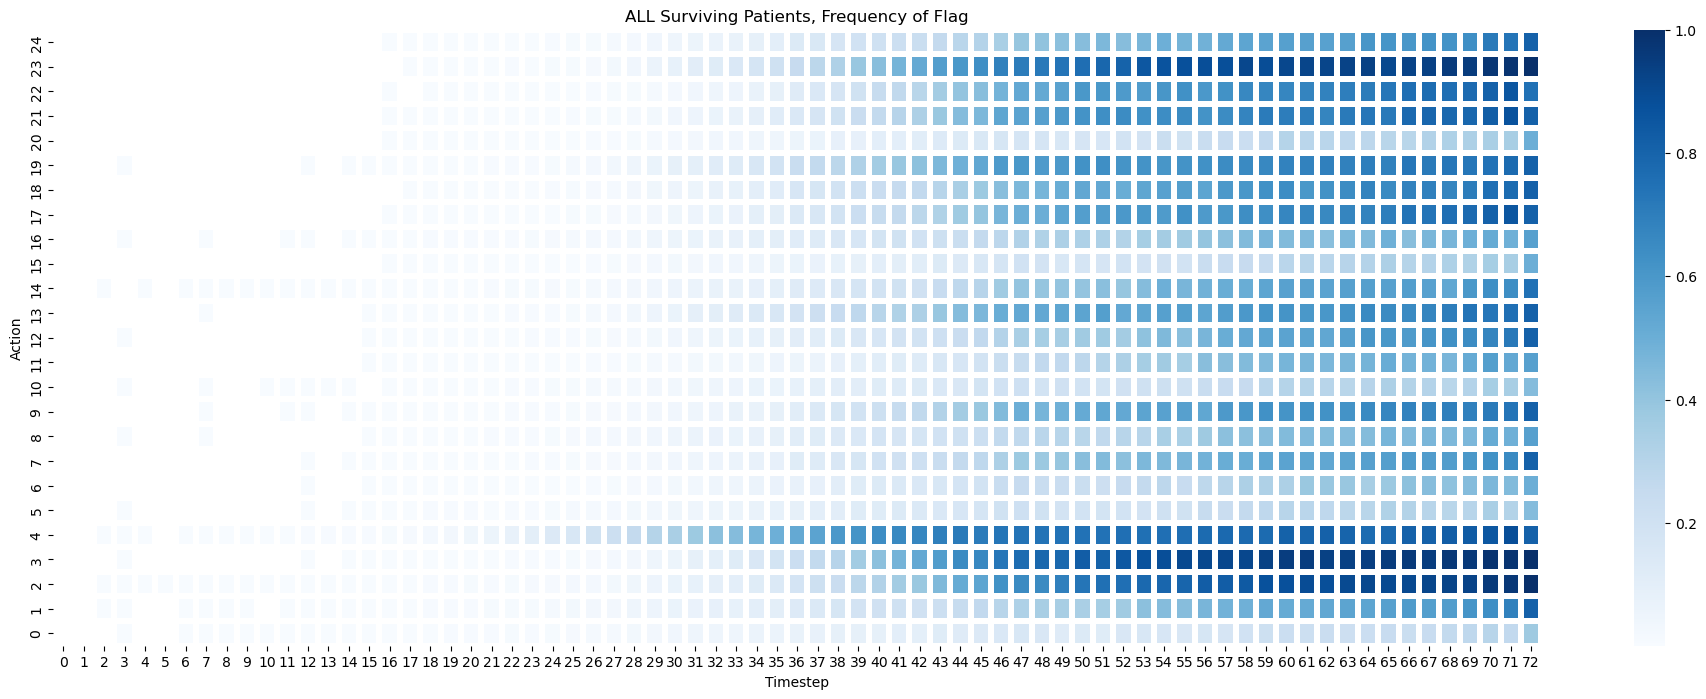

In [221]:
# Consider only surviving patients
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
for traj in surv_trajs:
    test_df = value_df[value_df.traj==traj]

    Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
    Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

    flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
    # flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
#     flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)
    flagged_acts = (flag_test[:, -1, :]).astype(int)  # Dimensions are num_steps (time) x num_acts, casting to integer
    
    num_steps = flagged_acts.shape[0]
    
    flagged_act_surv_comb.append(np.sum(flagged_acts, axis=-1)/flagged_acts.shape[-1])

    
    flag_counts_surv_comb[:num_steps, :] += flagged_acts
    # Account for the trajectory being "present" at each time step
    num_trajs_surv_comb[:num_steps, :] += np.ones_like(flagged_acts) 
    
normed_flag_counts = flag_counts_surv_comb/num_trajs_surv_comb
    
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_flag_counts), cmap='Blues', mask=np.transpose(normed_flag_counts==0), linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("ALL Surviving Patients, Frequency of Flag")
plt.show()

Min. Traj Lengths: 10
Average Traj Length: 40.32303164091243
Max. Traj Lengths: 73


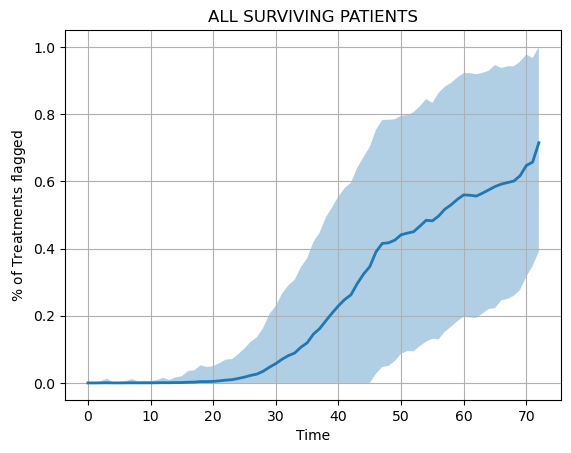

In [239]:
# Consolidate all of the arrays
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
lens = [len(i) for i in flagged_act_surv_comb]
print(f"Min. Traj Lengths: {np.min(lens)}")
print(f"Average Traj Length: {np.mean(lens)}")
print(f"Max. Traj Lengths: {np.max(lens)}")
arr = np.ma.empty((np.max(lens), len(flagged_act_surv_comb)))
arr.mask = True
for idx, l in enumerate(flagged_act_surv_comb):
    arr[:len(l), idx] = l
freq_mean, freq_std = arr.mean(axis=-1), arr.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2)
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), alpha=0.35)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL SURVIVING PATIENTS")
plt.show()

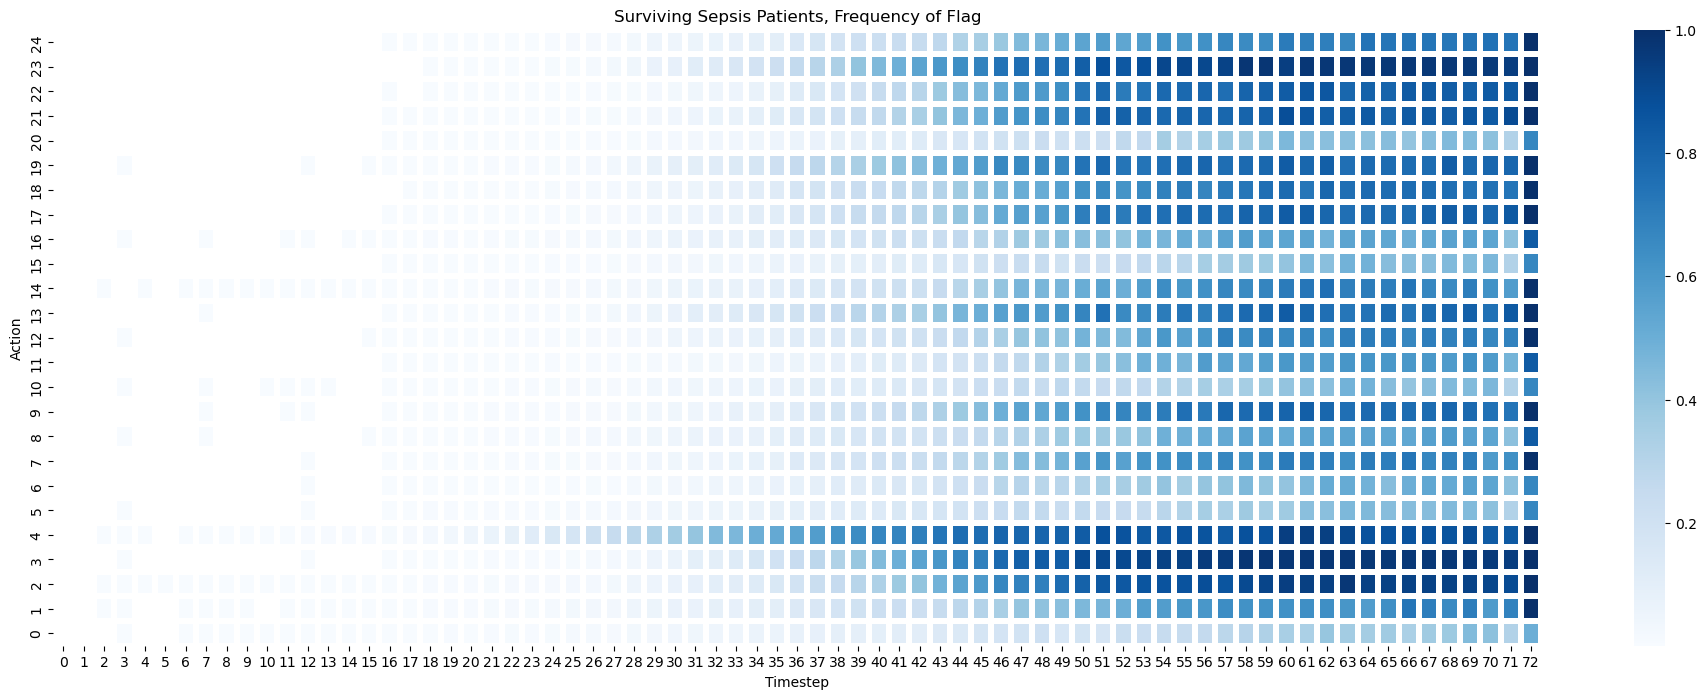

In [225]:
# Consider only surviving SEPSIS patients
for traj in surv_SEP_trajs:
    test_df = value_df[value_df.traj==traj]

    Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
    Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

#     flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
    # flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
    flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)
    flagged_acts = (flag_test[:, -1, :]).astype(int)  # Dimensions are num_steps (time) x num_acts, casting to integer
    
    num_steps = flagged_acts.shape[0]
    
    flagged_act_surv_SEP.append(np.sum(flagged_acts, axis=-1)/flagged_acts.shape[-1])

    
    flag_counts_surv_SEP[:num_steps, :] += flagged_acts
    # Account for the trajectory being "present" at each time step
    num_trajs_surv_SEP[:num_steps, :] += np.ones_like(flagged_acts) 
    
normed_flag_counts = flag_counts_surv_SEP/num_trajs_surv_SEP
    
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_flag_counts), cmap='Blues', mask=np.transpose(normed_flag_counts==0), linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("Surviving Sepsis Patients, Frequency of Flag")
plt.show()

Min. Traj Lengths: 10
Average Traj Length: 39.00373482726424
Max. Traj Lengths: 73


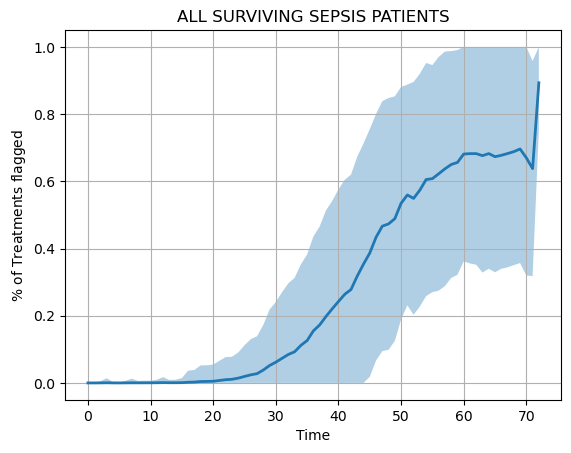

In [240]:
# Consolidate all of the arrays
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
lens = [len(i) for i in flagged_act_surv_SEP]
print(f"Min. Traj Lengths: {np.min(lens)}")
print(f"Average Traj Length: {np.mean(lens)}")
print(f"Max. Traj Lengths: {np.max(lens)}")
arr = np.ma.empty((np.max(lens), len(flagged_act_surv_SEP)))
arr.mask = True
for idx, l in enumerate(flagged_act_surv_SEP):
    arr[:len(l), idx] = l
freq_mean, freq_std = arr.mean(axis=-1), arr.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2)
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), alpha=0.35)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL SURVIVING SEPSIS PATIENTS")
plt.show()

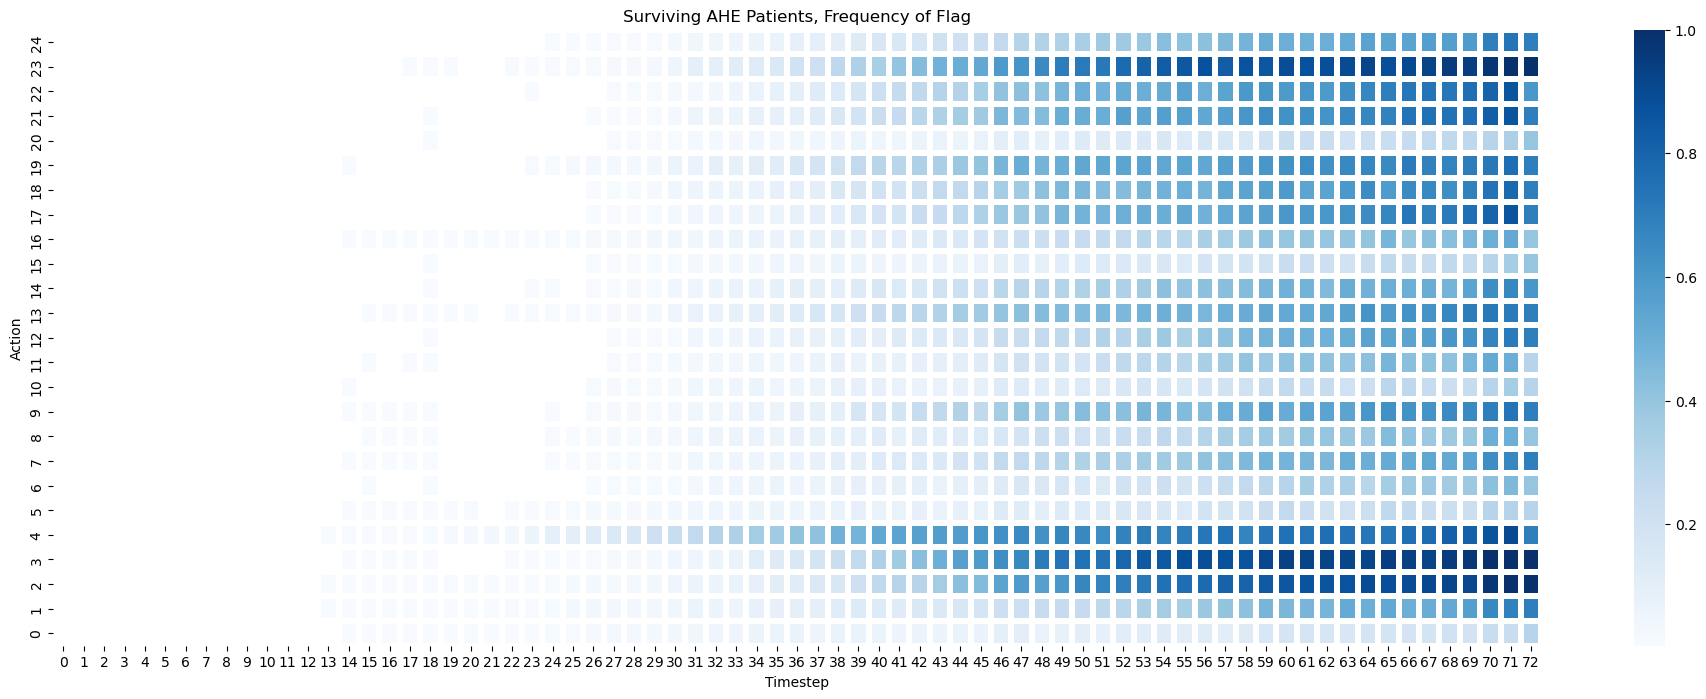

In [228]:
# Consider only nonsurviving SEPSIS patients
for traj in surv_AHE_trajs:
    test_df = value_df[value_df.traj==traj]

    Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
    Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])

#     flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
    flag_test = np.logical_and(Z_D<(thr_AHE-1), Z_R<thr_AHE)
#     flag_test = np.logical_and(Z_D<(thr_SEP-1), Z_R<thr_SEP)
    flagged_acts = (flag_test[:, -2, :]).astype(int)  # Dimensions are num_steps (time) x num_acts, casting to integer
    
    num_steps = flagged_acts.shape[0]
    
    flagged_act_surv_AHE.append(np.sum(flagged_acts, axis=-1)/flagged_acts.shape[-1])

    
    flag_counts_surv_AHE[:num_steps, :] += flagged_acts
    # Account for the trajectory being "present" at each time step
    num_trajs_surv_AHE[:num_steps, :] += np.ones_like(flagged_acts) 
    
normed_flag_counts = flag_counts_surv_AHE/num_trajs_surv_AHE
    
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_flag_counts), cmap='Blues', mask=np.transpose(normed_flag_counts==0), linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("Surviving AHE Patients, Frequency of Flag")
plt.show()

Min. Traj Lengths: 14
Average Traj Length: 45.229166666666664
Max. Traj Lengths: 73


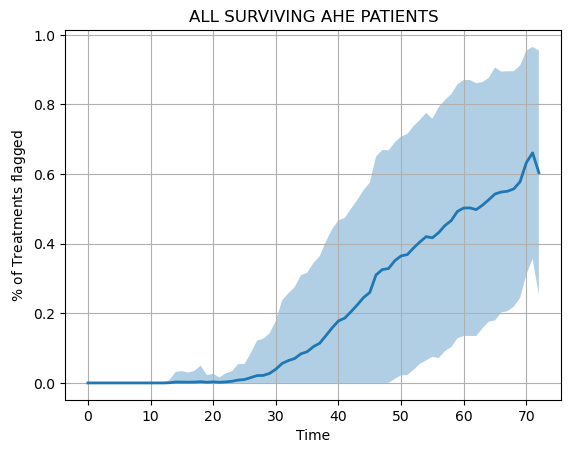

In [241]:
# Consolidate all of the arrays
# https://stackoverflow.com/questions/10058227/calculating-mean-of-arrays-with-different-lengths
lens = [len(i) for i in flagged_act_surv_AHE]
print(f"Min. Traj Lengths: {np.min(lens)}")
print(f"Average Traj Length: {np.mean(lens)}")
print(f"Max. Traj Lengths: {np.max(lens)}")
arr = np.ma.empty((np.max(lens), len(flagged_act_surv_AHE)))
arr.mask = True
for idx, l in enumerate(flagged_act_surv_AHE):
    arr[:len(l), idx] = l
freq_mean, freq_std = arr.mean(axis=-1), arr.std(axis=-1)

plt.figure()
plt.plot(np.arange(len(freq_mean)), freq_mean, lw=2)
plt.fill_between(np.arange(len(freq_mean)), np.maximum(0.0,freq_mean-freq_std), np.minimum(1.0, freq_mean+freq_std), alpha=0.35)
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"ALL SURVIVING AHE PATIENTS")
plt.show()

### Now, follow Marzyeh's suggestions...

(23 March '23) In a recent meeting, Marzyeh suggested that we look at the residual between AHE and Sepsis treatment flag frequencies. That way we can get a measure for which treatments are directly favored over time in comparison between the two patient subcohorts. Another suggestion she had was to weight by the "presence" of a particular action in the dataset. I'm very clear on what to do for the first one and not as clear on the second one...

In [268]:
# Let's take the frequencies of actions being flagged across AHE and Septic patients 
#    --> We want to compare to the "overlap" cohort 

normed_flag_counts_SEP = flag_counts_ns_SEP/num_trajs_ns_SEP
normed_flag_counts_AHE = flag_counts_ns_AHE/(num_trajs_ns_AHE + 1e-8)

normed_residual = normed_flag_counts_AHE - normed_flag_counts_SEP

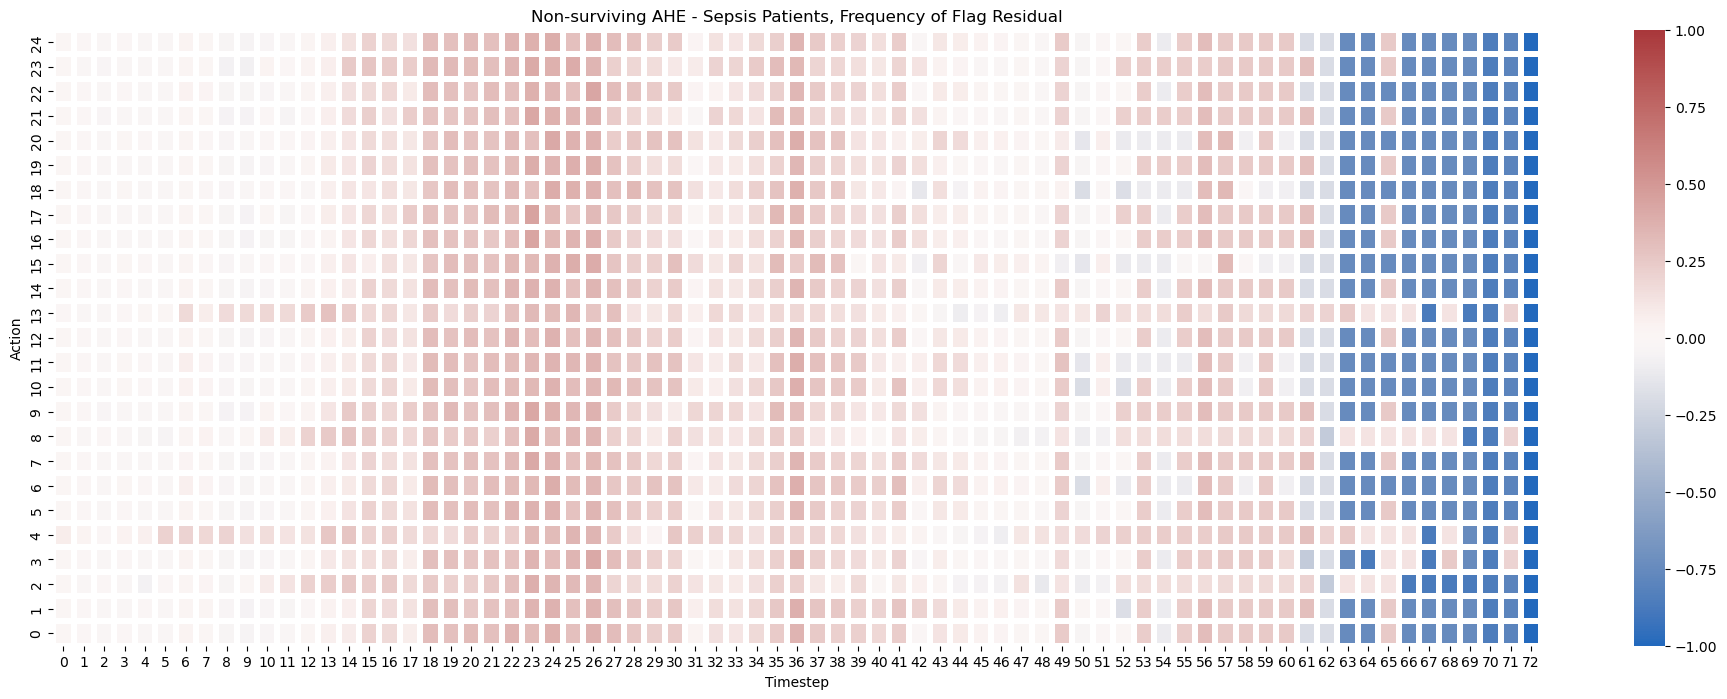

In [98]:
plt.figure(figsize=(24,8))
ax = sns.heatmap(np.transpose(normed_residual), cmap='vlag', vmin=-1.0, vmax=1.0, linewidths=3, linecolor='white')
ax.invert_yaxis()
plt.ylabel("Action")
plt.xlabel("Timestep")
plt.title("Non-surviving AHE - Sepsis Patients, Frequency of Flag Residual")
plt.show()

# Now, repeat these analyses for the OVERLAP Cohort

(24 March '23) There's something off about these initial examples so I tried re-running the evaluation script and it was feeding me back garbage in relation to what what we'd previously seen on the cohort + data evaluated above. So I feel the need to re-train the models using BayesOpt again. I feel as though the best performing models were corrupted when we ran the secondary analyses for our TMLR paper looking at reduced datasets and stronger CQL weightings...

So for now, this whole analysis is TBD 

In [243]:
# Load the outputs of the IQN+CQL trained models on the Overlap Data...
with open(os.path.join(metrics_dir, "IQN", "iqn_cql", "best_iqn_cql_overlap_value_data.pkl"), 'rb') as f:
    overlap_value_data = pickle.load(f)

In [244]:
# Extract the value data from this evaluation script, put it into a dataframe
# Get the patient type from the underlying full dataframe extracted from MIMIC
over_value_df = pd.DataFrame(overlap_value_data)

print(over_value_df.shape)
over_value_df.head()

(4175, 8)


,traj,step,s,a,q_dn,q_rn,category,stay_id
0,0,0,"[-0.2760849, 0.3724793, -1.1232256, -0.2495388...",0,"[[-0.3306417, -1.0, -1.0, -1.0, -1.0, -0.44034...","[[0.60674614, 0.0, 0.0, 0.0, 0.0, 0.5622679, 0...",1,30128855.0
1,0,1,"[-0.23517606, 0.61365056, -1.0856664, -0.49729...",0,"[[-0.31647855, -1.0, -1.0, -1.0, -1.0, -0.4523...","[[0.7673912, 0.0, 0.0, 0.0, 0.0, 0.6290624, 0....",1,30128855.0
2,0,2,"[-0.42352742, 0.80727726, -0.015575886, -0.141...",20,"[[-0.19711009, -1.0, -1.0, -1.0, -1.0, -0.3524...","[[0.76534903, 0.0, 0.0, 0.0, 0.0, 0.552739, 0....",1,30128855.0
3,0,3,"[0.44266433, 0.23624569, 0.6029885, -1.0631043...",20,"[[-0.928232, -1.0, -1.0, -1.0, -1.0, -0.827892...","[[0.39543003, 0.0, 0.0, 0.0, 0.0, 0.5679981, 0...",1,30128855.0
4,0,4,"[0.64277726, -0.2289746, 1.3180261, -1.587716,...",5,"[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...","[[0.2615494, 0.0, 0.0, 0.0, 0.0, 0.46528634, 0...",1,30128855.0


In [245]:
# Load the data!
over_test_data = data[data['m:stay_id'].isin(over_value_df.stay_id.unique())]

In [246]:
# This will get us whether the patient was Septic or experienced an AHE... (NEED TO RETHINK THIS...)
over_data_grp_ts = over_test_data.groupby('m:stay_id').apply(extract_first_relevant_ts)
over_value_df['presumed_onset'] = over_value_df['stay_id'].map(over_data_grp_ts)
over_value_df[['presumed_onset','pt_type']] = pd.DataFrame(over_value_df.presumed_onset.to_list(), index=over_value_df.index)

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [251]:
temp_df = over_value_df.groupby('traj', group_keys=False).apply(compute_cvar_etc).reset_index(drop=True)
print(temp_df.shape)
temp_df.head()

/pkgs/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/pkgs/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


(4175, 8)


,traj,step,cvar_dn,cvar_rn,dn_sel_act,rn_sel_act,v_dn,v_rn
0,0,0,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.22471603751182556, -0.163354694843292...","[nan, 0.6375309228897095, 0.661246657371521, 0...","[nan, -1.0, -1.0, -1.0, -1.0, -0.9949588775634...","[nan, 0.0, 0.0, 0.0, 0.0, 0.003835516050457954..."
1,0,1,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.1977350413799286, -0.1557456851005554...","[nan, 0.7988640666007996, 0.8123114705085754, ...","[nan, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0...","[nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,0,2,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.7022901773452759, -0.6029731631278992...","[nan, 0.13802725076675415, 0.28182440996170044...","[nan, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0...","[nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,0,3,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.03670229762792587, -0.022932920604944...","[nan, 0.9090670347213745, 0.9199771881103516, ...","[nan, -1.0, -0.9552472829818726, -0.8759186267...","[nan, 0.0, 0.0, 0.02692149206995964, 0.0790095..."
4,0,4,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, -0.8534547686576843, -0.6663367748260498...","[nan, 0.5216900110244751, 0.6007774472236633, ...","[nan, -1.0, -0.9068390727043152, -0.7834155559...","[nan, 0.0, 0.07438284158706665, 0.195514246821..."


In [253]:
# Now combine and merge the two dataframes so we can start operating more directly on it to construct the FPR/TPR
over_value_df = pd.merge(over_value_df, temp_df, how='outer', on=['traj','step'])

In [254]:
over_value_df.shape

(4175, 14)

## Now, look at % of Actions Flagged through Time

In [255]:
over_ns_trajs = over_value_df[over_value_df.category<0]['traj'].unique()
over_surv_trajs = over_value_df[over_value_df.category>0]['traj'].unique()


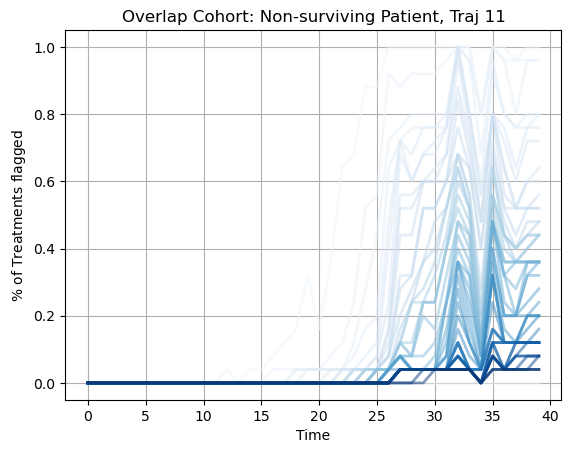

In [259]:
test_traj = over_ns_trajs[2]
over_test_df = over_value_df[over_value_df.traj==test_traj]

Z_D = np.vstack([j[None, ...] for j in test_df['cvar_dn'].values])
Z_R = np.vstack([j[None, ...] for j in test_df['cvar_rn'].values])
V_D = np.vstack([j[None, ...] for j in test_df['v_dn'].values])
V_R = np.vstack([j[None, ...] for j in test_df['v_rn'].values])

flag_test = np.logical_and(Z_D<(thr_comb-1), Z_R<thr_comb)
flag_summary = np.sum(flag_test, axis=-1)/flag_test.shape[-1]

colors = sns.color_palette("Blues", n_colors=flag_test.shape[1])
plt.figure()
for i in range(flag_test.shape[1]):
    plt.plot(np.arange(flag_test.shape[0]), flag_summary[:, i], lw=2, alpha=0.5, color=colors[i])
plt.grid()
plt.xlabel("Time")
plt.ylabel("$\%$ of Treatments flagged")
plt.title(f"Overlap Cohort: Non-surviving Patient, Traj {test_traj}")
plt.show()